In [1]:
# ─── SOURCE  (Starfire nGen-310 — CERN RP Safety File EDMS 3409579 §2.1) ─────
E0_MEV           = 2.45    # [MeV]  DD neutron energy (monoenergetic)
E0_SPREAD_KEV    = 50.0    # [keV]  ±1σ energy spread (doc: ±50 keV)

# ─── B-HDPE SHIELD  (doc §2.2) ───────────────────────────────────────────────
PE_THICKNESS_CM  = 14.0   # [cm]   lateral wall thickness (14 cm B-HDPE)
BHDPE_DENSITY    = 1.0    # [g/cm³]  (doc: 1.0 g/cm³)
BORON_MASS_FRAC  = 0.05   # boron mass fraction (doc: 5% by weight, natural boron)
B10_ENRICHMENT   = 0.199  # B-10 atom fraction (doc: natural boron)

# ─── WOOD LAYER (outer casing, downstream of the B-HDPE) ────────────────────
WOOD_THICKNESS_CM = 1.0   # [cm]   wood panel on the outside of the shield
WOOD_DENSITY      = 0.6   # [g/cm³] typical plywood / soft wood (assumed)
WOOD_H_FRAC       = 0.06  # dry-wood (cellulose-like) mass fractions
WOOD_C_FRAC       = 0.50
WOOD_O_FRAC       = 0.44  # oxygen treated as carbon-equivalent scatterer

TOTAL_SHIELD_CM   = PE_THICKNESS_CM + WOOD_THICKNESS_CM   # 15 cm stack

# ─── STEEL LAYER (in front of the far sample, Sample B) ──────────────────────
# Mild steel ≈ pure iron for neutron transport at these energies.
STEEL_DENSITY     = 7.85  # [g/cm³] mild steel
A_FE              = 55.85 # iron mass number (elastic kinematics)
SIGMA_FE_ABS_TH   = 2.56  # [barn]  Fe(n,γ) thermal capture, scaled 1/v

# ─── GEOMETRY & SAMPLES ──────────────────────────────────────────────────────
# Two identical 3×3×1 cm tiles are now placed downstream of the shield:
#   • Sample A: 5 cm of air after the shield outer face  → 20 cm from source.
#   • Sample B: 15 cm from the shield, with 0.5 cm of steel in the path
#               (rest air)                                → 30 cm from source.
# Air is transparent to neutrons, so only its thickness (→ distance, 1/r²)
# matters; the steel in front of Sample B both attenuates and (weakly) moderates
# the transmitted beam and is tracked explicitly in the MC.
#
# Isotropic emission, but only directions within a 20° cone around the slab
# normal (pointing at the tile) are tracked — neutrons emitted elsewhere cannot
# contribute to capture in the tile.
CONE_HALF_ANGLE_DEG = 20.0

SAMPLES = {
    'A': dict(label='Sample A — 5 cm air after shield',
              air_gap_cm=5.0,  steel_cm=0.0, color='darkorange'),
    'B': dict(label='Sample B — 15 cm from shield, 0.5 cm steel',
              air_gap_cm=15.0, steel_cm=0.5, color='steelblue'),
}
for _s in SAMPLES.values():
    _s['distance_cm'] = TOTAL_SHIELD_CM + _s['air_gap_cm']   # source → tile

# Reference values from doc §2.2 — for cross-checks against MC output:
MFP_DOC_CM       = 3.42   # [cm]   mean free path at 2.45 MeV
MACRO_XS_DOC     = 0.292  # [cm⁻¹] macroscopic total cross-section at 2.45 MeV

# lib_neutrons.get_mean_free_path() is hardcoded to rho = 0.95 g/cm³.
# Scale its output to match the actual B-HDPE density (number densities ∝ rho).
MFP_DENSITY_CORRECTION = 0.95 / BHDPE_DENSITY   # 0.95 for density 1.0

# B-10 capture cross-section (1/v law, ENDF/B-VIII.0)
SIGMA_B10_THERMAL_BARNS = 3840.0  # barns at E_THERMAL_EV
E_THERMAL_EV            = 0.0253  # eV (room temperature)

# ─── MONTE CARLO ─────────────────────────────────────────────────────────────
N_NEUTRONS       = 100_000 # number of neutrons to simulate
ABSORPTION_PROB  = 0.02   # H-capture probability per scattering collision
ENERGY_LOSS_FRAC = 0.5    # avg fractional energy loss per H-collision

# ─── PLOT ────────────────────────────────────────────────────────────────────
E_MIN_EV         = 0.01   # [eV]  lower axis limit
E_MAX_EV         = 4e6    # [eV]  upper axis limit


In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import numpy as np
import matplotlib.pyplot as plt
from lib_neutrons import calculate_moderated_spectrum, calculate_flux_fractions, get_mean_free_path

N_A   = 6.022e23
M_B10 = 10.0  # g/mol

# B-10 number density in B-HDPE
n_B10 = (BHDPE_DENSITY * BORON_MASS_FRAC * B10_ENRICHMENT / M_B10) * N_A  # cm⁻³

# Cross-check: MFP at 2.45 MeV after density correction vs. doc reference
mfp_lib  = get_mean_free_path(E0_MEV * 1e6) * MFP_DENSITY_CORRECTION
print(f"B-10 number density          : {n_B10:.3e} cm⁻³")
print(f"MFP at 2.45 MeV (lib×corr)  : {mfp_lib:.2f} cm  (doc: {MFP_DOC_CM} cm)")
print(f"Σ   at 2.45 MeV (lib×corr)  : {1/mfp_lib:.3f} cm⁻¹  (doc: {MACRO_XS_DOC} cm⁻¹)")

# ── Analytical moderation (plain PE model — boron does not scatter) ──────────
E0_kev               = E0_MEV * 1e3
initial_energies_kev = np.logspace(-3, 4, 2000)
sigma_kev            = E0_SPREAD_KEV                    # ±50 keV from doc
initial_spectrum     = np.exp(-0.5 * ((initial_energies_kev - E0_kev) / sigma_kev) ** 2)

mod_E_kev, mod_spectrum = calculate_moderated_spectrum(
    initial_energies_kev, initial_spectrum,
    hdpe_thickness_cm=PE_THICKNESS_CM)

# ── Apply B-10 capture suppression (approximate post-correction) ─────────────
mod_E_eV     = mod_E_kev * 1e3
sigma_B10    = SIGMA_B10_THERMAL_BARNS * np.sqrt(E_THERMAL_EV / np.maximum(mod_E_eV, E_THERMAL_EV))
Sigma_B10    = n_B10 * sigma_B10 * 1e-24
B10_survival = np.exp(-Sigma_B10 * PE_THICKNESS_CM)
mod_spectrum_bhdpe = mod_spectrum * B10_survival

fracs_pe    = calculate_flux_fractions(mod_E_kev, mod_spectrum)
fracs_bhdpe = calculate_flux_fractions(mod_E_kev, mod_spectrum_bhdpe)

print(f"\nAnalytical — plain PE vs B-HDPE ({BORON_MASS_FRAC*100:.0f}% B, natural)")
print(f"{'Region':<22} {'Plain PE':>10} {'B-HDPE':>10}")
print("-" * 44)
for key in ('cold', 'thermal', 'epithermal', 'fast'):
    print(f"  {key:<20} {fracs_pe[key]*100:>9.1f}% {fracs_bhdpe[key]*100:>9.1f}%")


✓ Particle Detectors Physics Library loaded successfully!
  - MaterialDatabase: 92 elements + 6 compounds
  - NuclearDatabase: 13 isotopes
  - Bethe-Bloch, neutron capture, and photon attenuation functions available
✓ lib_neutrons loaded: plotting, AmBe spectrum, moderation, ToF, ENDF data
B-10 number density          : 5.992e+20 cm⁻³
MFP at 2.45 MeV (lib×corr)  : 3.23 cm  (doc: 3.42 cm)
Σ   at 2.45 MeV (lib×corr)  : 0.309 cm⁻¹  (doc: 0.292 cm⁻¹)

Analytical — plain PE vs B-HDPE (5% B, natural)
Region                   Plain PE     B-HDPE
--------------------------------------------
  cold                       1.1%       0.0%
  thermal                   98.9%     100.0%
  epithermal                 0.0%       0.0%
  fast                       0.0%       0.0%


In [3]:
import time as time_module
from lib_neutrons import calculate_energy_fractions, get_endf_cross_sections

E0_eV  = E0_MEV * 1e6
N_A_mc = 6.022e23

# ── B-HDPE number densities (doc §2.2) ───────────────────────────────────────
BHDPE_H_FRAC = 0.143
BHDPE_C_FRAC = 0.807
n_H_bhdpe = (BHDPE_DENSITY * BHDPE_H_FRAC / 1.0)  * N_A_mc   # cm⁻³
n_C_bhdpe = (BHDPE_DENSITY * BHDPE_C_FRAC / 12.0) * N_A_mc   # cm⁻³

# ── Wood number densities (O folded into C: similar σ, A close enough) ───────
n_H_wood   = (WOOD_DENSITY * WOOD_H_FRAC / 1.0)  * N_A_mc
n_C_wood   = (WOOD_DENSITY * WOOD_C_FRAC / 12.0) * N_A_mc
n_O_wood   = (WOOD_DENSITY * WOOD_O_FRAC / 16.0) * N_A_mc
n_Ceq_wood = n_C_wood + n_O_wood

# ── Steel (iron) number density ──────────────────────────────────────────────
n_Fe = (STEEL_DENSITY / A_FE) * N_A_mc
print(f"B-HDPE: n_H = {n_H_bhdpe:.3e}   n_C    = {n_C_bhdpe:.3e} cm⁻³")
print(f"Wood  : n_H = {n_H_wood:.3e}   n_C+O = {n_Ceq_wood:.3e} cm⁻³")
print(f"Steel : n_Fe = {n_Fe:.3e} cm⁻³")

# ── Iron elastic cross section (barns), smooth ENDF/B-VIII.0 approximation ────
# Log-log interpolation of a coarse point set; the sharp resonances of Fe
# (e.g. the 27.7 keV window) are deliberately averaged out — adequate for a
# thin 0.5 cm slab (≈0.12 mean free paths at 2.45 MeV).
_FE_E_TBL = np.array([1e-2, 1e0, 1e2, 1e3, 1e4, 3e4, 5e4, 1e5, 3e5, 5e5, 1e6, 2.45e6, 5e6])
_FE_S_TBL = np.array([11.4, 11.3, 11.2, 11.1, 11.0, 10.0, 8.0, 6.5, 4.2, 3.8, 3.2,  2.9,  2.5])
def sigma_Fe(E_eV):
    E_eV = np.atleast_1d(np.asarray(E_eV, float))
    return 10 ** np.interp(np.log10(E_eV), np.log10(_FE_E_TBL), np.log10(_FE_S_TBL))

# ── Per-material scatter tables in log-E space (H + heavy scatterer) ──────────
_E_tbl           = np.logspace(np.log10(0.025), np.log10(E0_eV * 1.5), 2000)
_sH_tbl, _sC_tbl = get_endf_cross_sections(_E_tbl)
_sFe_tbl         = sigma_Fe(_E_tbl)
_logE_tbl        = np.log(_E_tbl)

def make_layer(name, thickness, z0, n_H, n_heavy, sigma_heavy_tbl,
               A_heavy, n_abs, sigma_abs_th, abs_is_boron):
    """One planar material slab [z0, z0+thickness).

    n_abs / sigma_abs_th describe a 1/v absorber (B-10 in B-HDPE, Fe(n,γ) in
    steel); abs_is_boron flags captures that count as the B-10 signal.
    """
    Ss = (n_H * _sH_tbl + n_heavy * sigma_heavy_tbl) * 1e-24            # Σ_scatter [cm⁻¹]
    fH = (n_H * _sH_tbl * 1e-24) / Ss                                  # H-scatter fraction
    return dict(name=name, z0=z0, z1=z0 + thickness, thickness=thickness,
                A_heavy=A_heavy, n_abs=n_abs, sigma_abs_th=sigma_abs_th,
                abs_is_boron=abs_is_boron, Ss=Ss, fH=fH)

def build_stack(steel_cm):
    """Layer stack for a sample: B-HDPE + wood, optionally + steel slab."""
    L = [make_layer('B-HDPE', PE_THICKNESS_CM, 0.0, n_H_bhdpe, n_C_bhdpe,
                    _sC_tbl, 12.0, n_B10, SIGMA_B10_THERMAL_BARNS, True)]
    L.append(make_layer('wood', WOOD_THICKNESS_CM, L[-1]['z1'], n_H_wood,
                         n_Ceq_wood, _sC_tbl, 12.0, 0.0, 0.0, False))
    if steel_cm > 0:
        L.append(make_layer('steel', steel_cm, L[-1]['z1'], 0.0, n_Fe,
                             _sFe_tbl, A_FE, n_Fe, SIGMA_FE_ABS_TH, False))
    return L

def Sigma_scatter_of(E, layer):
    return float(np.interp(np.log(max(E, 0.025)), _logE_tbl, layer['Ss']))

def h_frac(E, layer):
    return float(np.interp(np.log(max(E, 0.025)), _logE_tbl, layer['fH']))

# sanity print on the B-HDPE layer
_bh = build_stack(0.0)[0]
print(f"MFP at 2.45 MeV in B-HDPE      : {1/Sigma_scatter_of(E0_eV, _bh):.2f} cm  (doc: {MFP_DOC_CM} cm)")
print(f"H-scatter fraction at 2.45 MeV : {h_frac(E0_eV, _bh)*100:.1f}% (B-HDPE)")
_sfe0 = float(sigma_Fe(E0_eV)[0])
print(f"Fe elastic σ at 2.45 MeV       : {_sfe0:.2f} b  "
      f"→ MFP {1/(n_Fe*_sfe0*1e-24):.2f} cm in steel")

# ── Neutron speed [cm/s] from kinetic energy (non-relativistic) ──────────────
# v = sqrt(2E/m);  1.3831e6 cm/s per sqrt(eV)  →  2.20e5 cm/s at 25.3 meV.
def neutron_velocity(E_eV):
    return 1.3831e6 * np.sqrt(np.maximum(E_eV, 1e-6))

# ── Direction-update: apply scatter angle θ to current direction cosine μ ─────
def update_mu(mu, cos_theta):
    sin_theta = np.sqrt(max(1.0 - cos_theta**2, 0.0))
    sin_mu    = np.sqrt(max(1.0 - mu**2,        0.0))
    if sin_mu < 1e-10:                         # moving exactly along ±z
        return cos_theta if mu > 0 else -cos_theta
    cos_phi = 2.0 * np.random.random() - 1.0
    return mu * cos_theta + sin_mu * sin_theta * cos_phi

def layer_of(pos, layers):
    for k, l in enumerate(layers):
        if pos < l['z1'] - 1e-12:
            return k
    return len(layers) - 1

def run_shield_mc(layers, N=N_NEUTRONS, label=''):
    """1-D layered-slab single-track MC through an arbitrary material stack.

    Neutrons start at z=0 with μ₀ isotropic inside the 20° cone and are tracked
    with exact H (A=1) and heavy-nucleus (A=12 C, A=56 Fe) elastic kinematics
    until they exit forward (transmitted), exit backward (backscattered), or are
    captured.  Returns per-neutron arrays plus a fate summary.
    """
    Zexit  = layers[-1]['z1']
    MU_MIN = np.cos(np.radians(CONE_HALF_ANGLE_DEG))
    EPS    = 1e-9

    E_final     = np.zeros(N)
    t_arr       = np.zeros(N)          # [s] accumulated transit time in the stack
    n_coll_arr  = np.zeros(N, dtype=int)
    absorbed    = np.zeros(N, dtype=bool)
    abs_by_boron= np.zeros(N, dtype=bool)
    transmitted = np.zeros(N, dtype=bool)

    stack_str = ' + '.join(f"{l['thickness']:g}cm {l['name']}" for l in layers)
    print(f"\nMC [{label}]: {N:,} n at {E0_MEV} MeV through {stack_str}")
    t0 = time_module.time()

    for i in range(N):
        E   = E0_eV
        pos = 0.0
        t   = 0.0
        mu  = MU_MIN + (1.0 - MU_MIN) * np.random.random()
        n_coll = 0
        dead = False; boron = False; trans = False

        while True:
            lay = layers[layer_of(pos, layers)]

            Sigma_scatter = Sigma_scatter_of(E, lay)
            sigma_abs     = lay['sigma_abs_th'] * np.sqrt(E_THERMAL_EV / max(E, E_THERMAL_EV))
            Sigma_abs     = lay['n_abs'] * sigma_abs * 1e-24
            Sigma_total   = Sigma_scatter + Sigma_abs
            step          = -np.log(np.random.random()) / Sigma_total

            if mu > 0:
                dist_face = (lay['z1'] - pos) / mu
            elif mu < 0:
                dist_face = (pos - lay['z0']) / (-mu)
            else:
                dist_face = 1e30

            if step >= dist_face:
                t   += dist_face / neutron_velocity(E)
                pos += dist_face * mu + EPS * np.sign(mu)
                if pos >= Zexit:
                    trans = True; break
                if pos <= 0.0:
                    trans = False; break
                continue

            t      += step / neutron_velocity(E)
            pos    += step * mu
            n_coll += 1

            # ── 1/v absorber (B-10 in B-HDPE, Fe(n,γ) in steel) ──────────────
            if np.random.random() * Sigma_total < Sigma_abs:
                dead = True; boron = lay['abs_is_boron']; break

            # ── elastic scatter: H or heavy nucleus ──────────────────────────
            if np.random.random() < h_frac(E, lay):
                c  = np.sqrt(np.random.random())          # cosθ_lab, H (A=1)
                E  = max(E * c * c, 0.025)
                mu = update_mu(mu, c)
                if np.random.random() < ABSORPTION_PROB:  # H radiative capture
                    dead = True; break
            else:
                A      = lay['A_heavy']                    # C (12) or Fe (56)
                cos_CM = 2.0 * np.random.random() - 1.0
                denom  = 1.0 + 2.0 * A * cos_CM + A**2
                E      = max(E * denom / (A + 1.0)**2, 0.025)
                c      = (1.0 + A * cos_CM) / np.sqrt(denom)
                mu     = update_mu(mu, c)

        E_final[i]      = E
        t_arr[i]        = t
        n_coll_arr[i]   = n_coll
        absorbed[i]     = dead
        abs_by_boron[i] = boron
        transmitted[i]  = trans

    elapsed = time_module.time() - t0
    n_surv  = int(np.sum(transmitted))
    n_back  = int(np.sum(~absorbed & ~transmitted))
    n_B10   = int(np.sum(abs_by_boron))
    n_H_cap = int(np.sum(absorbed & ~abs_by_boron))
    fr      = calculate_energy_fractions(E_final[transmitted])

    print(f"  ✓ {elapsed:.1f}s | transmitted {n_surv:,} ({100*n_surv/N:.2f}%) | "
          f"backscatt {100*n_back/N:.1f}% | B-10 cap {100*n_B10/N:.1f}% | H cap {100*n_H_cap/N:.1f}%")
    t_tr = t_arr[transmitted]
    print(f"    moderation time in stack: median {np.median(t_tr)*1e6:.3f} µs | "
          f"mean {np.mean(t_tr)*1e6:.3f} µs | max {np.max(t_tr)*1e6:.2f} µs")
    print(f"    transmitted spectrum: thermal {fr['thermal']*100:.1f}% | "
          f"epi {fr['epithermal']*100:.1f}% | fast {fr['fast']*100:.1f}% | "
          f"mean {fr['mean_eV']:.2g} eV | median {fr['median_eV']:.2g} eV | "
          f"mean coll {np.mean(n_coll_arr[transmitted]):.1f}")

    return dict(E_final=E_final, n_coll=n_coll_arr, absorbed=absorbed,
                abs_by_boron=abs_by_boron, transmitted=transmitted, t_all=t_arr,
                t_shield=t_arr[transmitted],
                E_surv=E_final[transmitted], transmission=n_surv / N,
                n_surv=n_surv, n_back=n_back, n_abs_B10=n_B10, n_abs_H=n_H_cap,
                fracs=fr)

np.random.seed(20260724)   # fixed seed → reproducible quoted rates
# ── Run the MC once per sample (identical B-HDPE+wood shield; Sample B adds steel)
RES = {}
for key, s in SAMPLES.items():
    RES[key] = run_shield_mc(build_stack(s['steel_cm']), label=s['label'])
    RES[key]['distance_cm'] = s['distance_cm']


B-HDPE: n_H = 8.611e+22   n_C    = 4.050e+22 cm⁻³
Wood  : n_H = 2.168e+22   n_C+O = 2.499e+22 cm⁻³
Steel : n_Fe = 8.464e+22 cm⁻³
MFP at 2.45 MeV in B-HDPE      : 3.29 cm  (doc: 3.42 cm)
H-scatter fraction at 2.45 MeV : 72.4% (B-HDPE)
Fe elastic σ at 2.45 MeV       : 2.90 b  → MFP 4.07 cm in steel

MC [Sample A — 5 cm air after shield]: 100,000 n at 2.45 MeV through 14cm B-HDPE + 1cm wood


  ✓ 5.0s | transmitted 7,177 (7.18%) | backscatt 16.3% | B-10 cap 53.2% | H cap 23.3%
    moderation time in stack: median 0.009 µs | mean 0.152 µs | max 28.02 µs
    transmitted spectrum: thermal 6.0% | epi 26.3% | fast 66.9% | mean 1.2e+06 eV | median 1.2e+06 eV | mean coll 4.2

MC [Sample B — 15 cm from shield, 0.5 cm steel]: 100,000 n at 2.45 MeV through 14cm B-HDPE + 1cm wood + 0.5cm steel


  ✓ 5.0s | transmitted 6,596 (6.60%) | backscatt 16.0% | B-10 cap 53.9% | H cap 23.5%
    moderation time in stack: median 0.010 µs | mean 0.255 µs | max 73.36 µs
    transmitted spectrum: thermal 5.8% | epi 24.2% | fast 69.1% | mean 1.3e+06 eV | median 1.3e+06 eV | mean coll 4.3


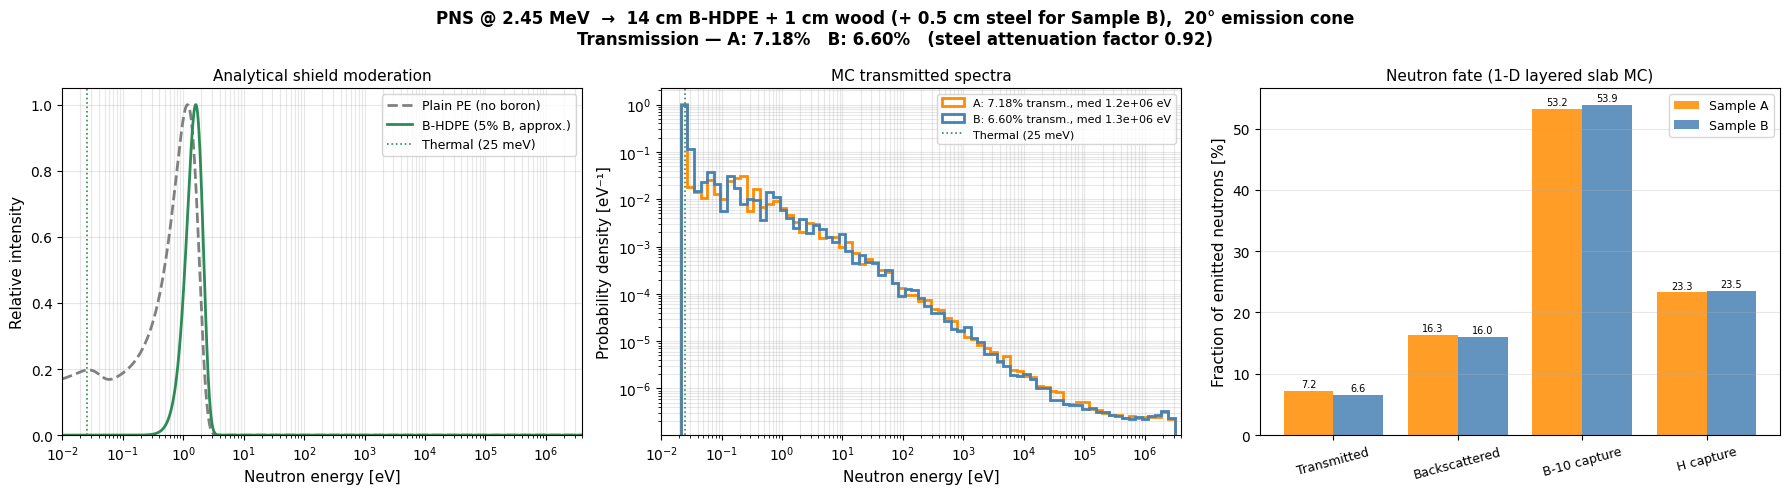

Saved → pns_bhdpe_spectrum.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Left: analytical — plain PE vs B-HDPE (shield only, sample-independent) ───
ax = axes[0]
norm_pe    = np.max(mod_spectrum)       if np.max(mod_spectrum)       > 0 else 1
norm_bhdpe = np.max(mod_spectrum_bhdpe) if np.max(mod_spectrum_bhdpe) > 0 else 1
ax.semilogx(mod_E_eV, mod_spectrum       / norm_pe,    color='gray',      lw=2,
            ls='--', label='Plain PE (no boron)')
ax.semilogx(mod_E_eV, mod_spectrum_bhdpe / norm_bhdpe, color='seagreen',  lw=2,
            label=f'B-HDPE ({BORON_MASS_FRAC*100:.0f}% B, approx.)')
ax.axvline(0.0253, color='seagreen', ls=':', lw=1.2, label='Thermal (25 meV)')
ax.set_xlabel('Neutron energy [eV]', fontsize=11)
ax.set_ylabel('Relative intensity', fontsize=11)
ax.set_title('Analytical shield moderation', fontsize=11)
ax.set_xlim(E_MIN_EV, E_MAX_EV)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# ── Centre: MC transmitted spectra, both samples overlaid ────────────────────
ax2  = axes[1]
bins = np.logspace(np.log10(E_MIN_EV), np.log10(E_MAX_EV), 80)
for key, s in SAMPLES.items():
    ax2.hist(RES[key]['E_surv'], bins=bins, histtype='step', lw=2,
             color=s['color'], density=True,
             label=f"{key}: {RES[key]['transmission']*100:.2f}% transm., "
                   f"med {RES[key]['fracs']['median_eV']:.2g} eV")
ax2.axvline(0.0253, color='seagreen', ls=':', lw=1.2, label='Thermal (25 meV)')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('Neutron energy [eV]', fontsize=11)
ax2.set_ylabel('Probability density [eV⁻¹]', fontsize=11)
ax2.set_title('MC transmitted spectra', fontsize=11)
ax2.set_xlim(E_MIN_EV, E_MAX_EV)
ax2.legend(fontsize=8)
ax2.grid(True, which='both', alpha=0.3)

# ── Right: neutron fate breakdown, grouped bars A vs B ───────────────────────
ax3      = axes[2]
cats     = ['Transmitted', 'Backscattered', 'B-10 capture', 'H capture']
keys     = list(SAMPLES.keys())
x        = np.arange(len(cats))
w        = 0.8 / len(keys)
for j, key in enumerate(keys):
    r    = RES[key]
    vals = [r['n_surv'], r['n_back'], r['n_abs_B10'], r['n_abs_H']]
    vals = [100 * v / N_NEUTRONS for v in vals]
    ax3.bar(x + (j - (len(keys)-1)/2) * w, vals, w,
            color=SAMPLES[key]['color'], alpha=0.85, label=f'Sample {key}')
    for xi, v in zip(x + (j - (len(keys)-1)/2) * w, vals):
        ax3.text(xi, v + 0.6, f'{v:.1f}', ha='center', fontsize=7)
ax3.set_xticks(x); ax3.set_xticklabels(cats, fontsize=9, rotation=15)
ax3.set_ylabel('Fraction of emitted neutrons [%]', fontsize=11)
ax3.set_title('Neutron fate (1-D layered slab MC)', fontsize=11)
ax3.legend(fontsize=9)
ax3.grid(True, axis='y', alpha=0.3)

fig.suptitle(
    f'PNS @ {E0_MEV} MeV  →  {PE_THICKNESS_CM:.0f} cm B-HDPE + {WOOD_THICKNESS_CM:.0f} cm wood '
    f'(+ 0.5 cm steel for Sample B),  {CONE_HALF_ANGLE_DEG:.0f}° emission cone\n'
    f"Transmission — A: {RES['A']['transmission']*100:.2f}%   "
    f"B: {RES['B']['transmission']*100:.2f}%   "
    f"(steel attenuation factor {RES['B']['transmission']/RES['A']['transmission']:.2f})",
    fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('pns_bhdpe_spectrum.png', dpi=120)
plt.show()
print("Saved → pns_bhdpe_spectrum.png")


In [5]:
# ─── Parameters ──────────────────────────────────────────────────────────────
EMISSION_RATE      = 1e7   # [n/s]  source rate (doc max: 1e7 n/s)
SURFACE_AREA_CM2   = 9.0   # [cm²]  detector surface (3×3 cm tile)

# ─── Flux at each sample (isotropic point source, 1/r² beyond the shield) ─────
# The MC gives the survival fraction for neutrons emitted within the 20° cone
# toward the tile.  Beyond the shield the field is treated as isotropic → 1/r²
# dilution only.  The steel slab in Sample B is already folded into its MC
# transmission, so only geometry (distance) is applied here.
print(f"Source emission rate : {EMISSION_RATE:.1e} n/s\n")
print(f"{'Sample':<8}{'dist':>7}{'steel':>7}{'transm.':>9}"
      f"{'flux':>13}{'R_surface':>12}{'tile ½-angle':>14}")
print(f"{'':<8}{'[cm]':>7}{'[cm]':>7}{'[%]':>9}{'[n/cm²/s]':>13}{'[n/s]':>12}{'[deg]':>14}")
print("-" * 71)
for key, s in SAMPLES.items():
    r   = RES[key]
    d   = r['distance_cm']
    T   = r['transmission']
    flux_cm2_s   = EMISSION_RATE * T / (4 * np.pi * d**2)   # [n/cm²/s]
    rate_surface = flux_cm2_s * SURFACE_AREA_CM2            # [n/s]
    tile_half    = np.degrees(np.arctan(np.sqrt(SURFACE_AREA_CM2)/2 / d))
    r['flux_cm2_s']   = flux_cm2_s
    r['rate_surface'] = rate_surface
    print(f"{key:<8}{d:>7.0f}{s['steel_cm']:>7.1f}{T*100:>9.2f}"
          f"{flux_cm2_s:>13.1f}{rate_surface:>12.1f}{tile_half:>13.1f}°")

cone_frac = 0.5 * (1.0 - np.cos(np.radians(CONE_HALF_ANGLE_DEG)))
print(f"\nEmission cone solid-angle fraction : {cone_frac*100:.2f}% of 4π "
      f"(tile ½-angles above are well inside the {CONE_HALF_ANGLE_DEG:.0f}° cone)")
print(f"Flux ratio B/A = {RES['B']['flux_cm2_s']/RES['A']['flux_cm2_s']:.3f}  "
      f"(1/r²: {(RES['A']['distance_cm']/RES['B']['distance_cm'])**2:.3f} × "
      f"steel transm.: {RES['B']['transmission']/RES['A']['transmission']:.3f})")


Source emission rate : 1.0e+07 n/s

Sample     dist  steel  transm.         flux   R_surface  tile ½-angle
           [cm]   [cm]      [%]    [n/cm²/s]       [n/s]         [deg]
-----------------------------------------------------------------------
A            20    0.0     7.18        142.8      1285.0          4.3°
B            30    0.5     6.60         58.3       524.9          2.9°

Emission cone solid-angle fraction : 3.02% of 4π (tile ½-angles above are well inside the 20° cone)
Flux ratio B/A = 0.408  (1/r²: 0.444 × steel transm.: 0.919)


In [6]:
# ─── Scintillator parameters (both tiles are identical) ──────────────────────
SCINT_THICKNESS_CM   = 1.0    # [cm]   sample thickness
SCINT_DENSITY        = 1.05   # [g/cm³] typical plastic scintillator (PVT/PS)
SCINT_BORON_FRAC     = 0.02   # boron mass fraction (2% doping)
SCINT_B10_ENRICHMENT = 0.199  # B-10 atom fraction (natural boron)

N_A_loc   = 6.022e23
M_B10_loc = 10.0
n_B10_scint = (SCINT_DENSITY * SCINT_BORON_FRAC * SCINT_B10_ENRICHMENT / M_B10_loc) * N_A_loc

print(f"Scintillator: {SCINT_THICKNESS_CM} cm thick, ρ = {SCINT_DENSITY} g/cm³, "
      f"B = {SCINT_BORON_FRAC*100:.0f}% wt (natural)   →   n_B10 = {n_B10_scint:.3e} cm⁻³\n")

# ─── B-10 capture probability & event rate, per sample ───────────────────────
# For each transmitted neutron, p(E) = 1 − exp(−Σ_B10(E)·t), σ_B10 ∝ 1/v.
groups = [
    ("thermal   (<1 eV)",           lambda E: E <  1.0),
    ("epithermal (1 eV–100 keV)",   lambda E: (E >= 1.0) & (E < 1e5)),
    ("fast      (>100 keV)",        lambda E: E >= 1e5),
]

for key in SAMPLES:
    r      = RES[key]
    E_surv = r['E_surv']
    sigma_b10 = SIGMA_B10_THERMAL_BARNS * np.sqrt(E_THERMAL_EV / np.maximum(E_surv, E_THERMAL_EV))
    Sigma_b10 = n_B10_scint * sigma_b10 * 1e-24                       # [cm⁻¹]
    p_interact = 1.0 - np.exp(-Sigma_b10 * SCINT_THICKNESS_CM)
    r['p_interact'] = p_interact
    r['mean_p']     = float(np.mean(p_interact))
    r['event_rate'] = r['rate_surface'] * r['mean_p']                 # [events/s] @ 100% duty

    print(f"── {SAMPLES[key]['label']}  ({r['distance_cm']:.0f} cm) "
          f"{'─'*max(0, 34-len(SAMPLES[key]['label']))}")
    print(f"   ⟨p⟩ = {r['mean_p']*100:.3f}%   "
          f"R_surface = {r['rate_surface']:.1f} n/s   "
          f"→  R_B10 = {r['event_rate']:.3f} events/s (100% duty)")
    print(f"                                      = {r['event_rate']*3600:.0f} events/hr "
          f"= {r['event_rate']*3600*24:.2e} events/day")
    for label, sel in groups:
        mask = sel(E_surv)
        if np.any(mask):
            print(f"     {label:<26}: p = {np.mean(p_interact[mask])*100:6.3f}%  "
                  f"({100*np.sum(mask)/len(E_surv):4.1f}% of transmitted)")
    print()

print("Summary — 100%-duty B-10 capture rate:")
print(f"   Sample A : {RES['A']['event_rate']:.3f} Hz")
print(f"   Sample B : {RES['B']['event_rate']:.3f} Hz   "
      f"(B/A = {RES['B']['event_rate']/RES['A']['event_rate']:.2f})")


Scintillator: 1.0 cm thick, ρ = 1.05 g/cm³, B = 2% wt (natural)   →   n_B10 = 2.517e+20 cm⁻³

── Sample A — 5 cm air after shield  (20 cm) ──
   ⟨p⟩ = 0.985%   R_surface = 1285.0 n/s   →  R_B10 = 12.662 events/s (100% duty)
                                      = 45584 events/hr = 1.09e+06 events/day
     thermal   (<1 eV)         : p = 38.139%  ( 1.8% of transmitted)
     epithermal (1 eV–100 keV) : p =  1.494%  (19.3% of transmitted)
     fast      (>100 keV)      : p =  0.015%  (78.9% of transmitted)

── Sample B — 15 cm from shield, 0.5 cm steel  (30 cm) 
   ⟨p⟩ = 0.994%   R_surface = 524.9 n/s   →  R_B10 = 5.215 events/s (100% duty)
                                      = 18775 events/hr = 4.51e+05 events/day
     thermal   (<1 eV)         : p = 38.691%  ( 1.8% of transmitted)
     epithermal (1 eV–100 keV) : p =  1.593%  (17.8% of transmitted)
     fast      (>100 keV)      : p =  0.015%  (80.4% of transmitted)

Summary — 100%-duty B-10 capture rate:
   Sample A : 12.662 Hz
   Sa

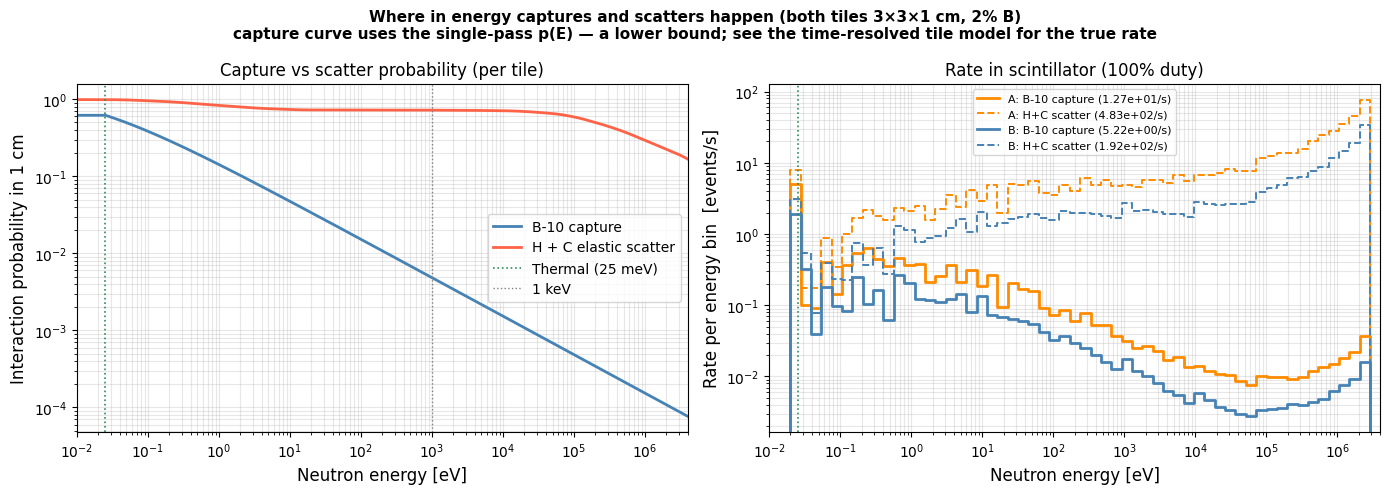

Sample A: single-pass capture 1.266e+01/s  |  H+C scatter 4.826e+02/s
Sample B: single-pass capture 5.215e+00/s  |  H+C scatter 1.923e+02/s


In [7]:
from lib_neutrons import get_endf_cross_sections

# ─── Scintillator composition (PVT ≈ C₉H₁₀, 2% B doping) — same for both tiles
SCINT_H_FRAC = (1.0 - SCINT_BORON_FRAC) * (10 / 118)    # ≈ 0.0830
SCINT_C_FRAC = (1.0 - SCINT_BORON_FRAC) * (108 / 118)   # ≈ 0.8967
n_H_scint = (SCINT_DENSITY * SCINT_H_FRAC / 1.0)  * N_A_loc
n_C_scint = (SCINT_DENSITY * SCINT_C_FRAC / 12.0) * N_A_loc

# ─── Interaction-probability curves in the scintillator (sample-independent) ──
E_grid = np.logspace(np.log10(E_MIN_EV), np.log10(E_MAX_EV), 500)
sigma_H_grid, sigma_C_grid = get_endf_cross_sections(E_grid)
Sigma_scatter_grid = (n_H_scint * sigma_H_grid + n_C_scint * sigma_C_grid) * 1e-24
sigma_b10_grid = SIGMA_B10_THERMAL_BARNS * np.sqrt(E_THERMAL_EV / np.maximum(E_grid, E_THERMAL_EV))
Sigma_b10_grid = n_B10_scint * sigma_b10_grid * 1e-24
p_scatter_grid = 1.0 - np.exp(-Sigma_scatter_grid * SCINT_THICKNESS_CM)
p_capture_grid = 1.0 - np.exp(-Sigma_b10_grid     * SCINT_THICKNESS_CM)

# ─── Rate per energy bin, weighted by each sample's MC spectrum ───────────────
bins = np.logspace(np.log10(E_MIN_EV), np.log10(E_MAX_EV), 60)
bin_centres = np.sqrt(bins[:-1] * bins[1:])
n_bins = len(bin_centres)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: interaction probability vs energy (one scintillator → one curve set)
ax1.loglog(E_grid, p_capture_grid, color='steelblue', lw=2, label='B-10 capture')
ax1.loglog(E_grid, p_scatter_grid, color='tomato',    lw=2, label='H + C elastic scatter')
ax1.axvline(0.0253, color='seagreen', ls=':', lw=1.2, label='Thermal (25 meV)')
ax1.axvline(1e3,    color='gray',     ls=':', lw=1.0, label='1 keV')
ax1.set_xlabel('Neutron energy [eV]', fontsize=12)
ax1.set_ylabel(f'Interaction probability in {SCINT_THICKNESS_CM:.0f} cm', fontsize=12)
ax1.set_title('Capture vs scatter probability (per tile)', fontsize=12)
ax1.set_xlim(E_MIN_EV, E_MAX_EV)
ax1.legend(fontsize=10); ax1.grid(True, which='both', alpha=0.3)

# Right: rate per energy bin, both samples
for key, s in SAMPLES.items():
    r        = RES[key]
    E_surv   = r['E_surv']
    sigma_H_mc, sigma_C_mc = get_endf_cross_sections(E_surv)
    Sigma_scatter_mc = (n_H_scint * sigma_H_mc + n_C_scint * sigma_C_mc) * 1e-24
    p_scatter_mc = 1.0 - np.exp(-Sigma_scatter_mc * SCINT_THICKNESS_CM)
    p_interact   = r['p_interact']
    bin_idx = np.digitize(E_surv, bins) - 1
    rate_cap = np.zeros(n_bins); rate_sca = np.zeros(n_bins)
    for k in range(n_bins):
        m = bin_idx == k
        if np.any(m):
            ff = np.sum(m) / len(E_surv)
            rate_cap[k] = r['rate_surface'] * ff * np.mean(p_interact[m])
            rate_sca[k] = r['rate_surface'] * ff * np.mean(p_scatter_mc[m])
    r['total_scatter_rate'] = float(np.sum(rate_sca))
    r['total_capture_rate'] = float(np.sum(rate_cap))
    ax2.step(bin_centres, rate_cap, where='mid', color=s['color'], lw=2,
             label=f'{key}: B-10 capture ({np.sum(rate_cap):.2e}/s)')
    ax2.step(bin_centres, rate_sca, where='mid', color=s['color'], lw=1.4, ls='--',
             label=f'{key}: H+C scatter ({np.sum(rate_sca):.2e}/s)')
ax2.axvline(0.0253, color='seagreen', ls=':', lw=1.2)
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('Neutron energy [eV]', fontsize=12)
ax2.set_ylabel('Rate per energy bin  [events/s]', fontsize=12)
ax2.set_title('Rate in scintillator (100% duty)', fontsize=12)
ax2.set_xlim(E_MIN_EV, E_MAX_EV)
ax2.legend(fontsize=8); ax2.grid(True, which='both', alpha=0.3)

fig.suptitle(
    'Where in energy captures and scatters happen (both tiles 3×3×1 cm, 2% B)\n'
    'capture curve uses the single-pass p(E) — a lower bound; see the '
    'time-resolved tile model for the true rate',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('scint_capture_vs_scatter.png', dpi=120)
plt.show()
# NOTE: the capture rate here uses the single-pass p(E) and is a lower bound —
# it ignores that a neutron thermalizes inside the tile and gets many chances.
# The time-resolved tile model (later cell) gives ~2x more captures.  The
# scatter/capture ratio quoted in the note comes from there, not from here.
for key in SAMPLES:
    r = RES[key]
    print(f"Sample {key}: single-pass capture {r['total_capture_rate']:.3e}/s  |  "
          f"H+C scatter {r['total_scatter_rate']:.3e}/s")


Arrival time at tile face — MC clock (shield transit + air flight):
                           median [µs]     mean [µs]    free-flight [µs]
  Sample A (20 cm)        0.013         0.451               0.013
  Sample B (30 cm)        0.019         1.135               0.019
  (the free-flight column is the old approximation, shown for comparison)

Reference single-energy free-flight ToF (µs):
energy                      A (20cm)      B (30cm)
2.45 MeV (source)            0.00924        0.0139
100 keV                       0.0457        0.0686
1 eV                            14.5          21.7
25 meV (thermal)                90.9           136


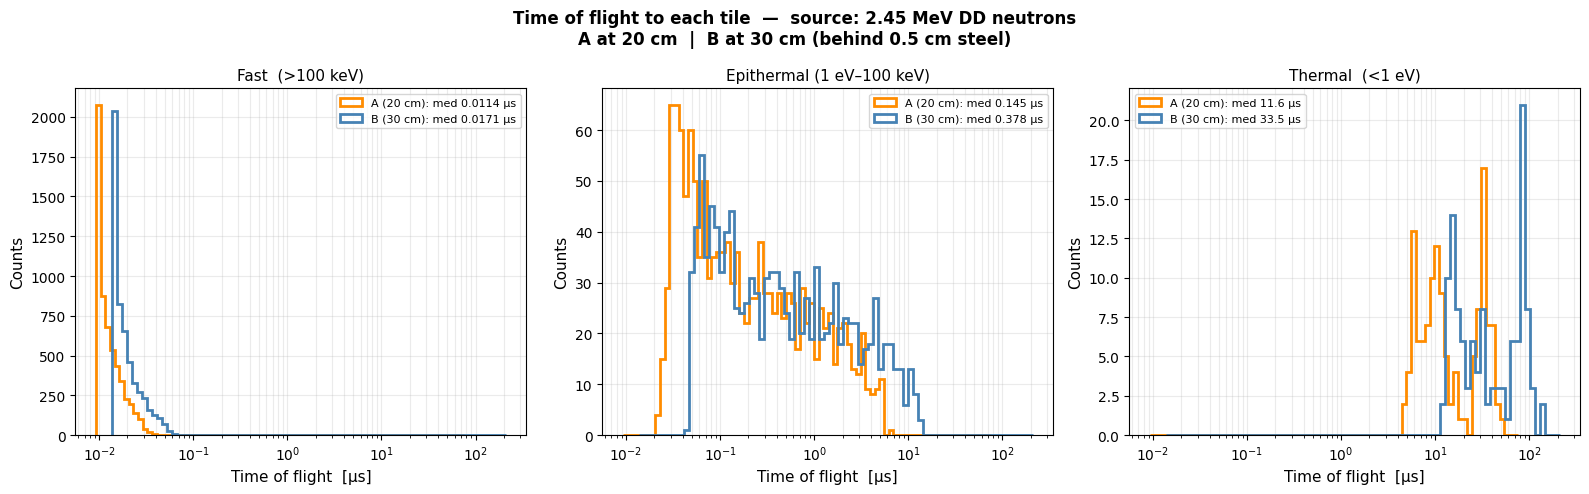

Saved → pns_tof_histograms.png


In [8]:
from lib_neutrons import tof_constant_energy

# ─── Arrival time at each tile face = shield transit + air flight ─────────────
# The shield transit time is now accumulated step-by-step inside the MC
# (Σ s/v), so slowing-down time is included.  Earlier versions of this notebook
# free-flighted the neutron from the shield exit at its *exit* energy, which
# discards the moderation time entirely.  Air flight is added at the exit
# energy over the remaining gap (air does not moderate).
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
group_defs = [
    (lambda E: E >= 1e5,                        'Fast  (>100 keV)',          axes[0]),
    (lambda E: (E >= 1.0) & (E < 1e5),          'Epithermal (1 eV–100 keV)', axes[1]),
    (lambda E: E < 1.0,                         'Thermal  (<1 eV)',          axes[2]),
]

for key, s in SAMPLES.items():
    r      = RES[key]
    d      = r['distance_cm']
    z_exit = TOTAL_SHIELD_CM + s['steel_cm']        # back face of the MC stack
    air_cm = d - z_exit                            # remaining air path to tile
    t_air  = air_cm / neutron_velocity(r['E_surv'])
    tof_us = (r['t_shield'] + t_air) * 1e6
    r['t_air'] = t_air
    r['t_arrive'] = r['t_shield'] + t_air          # [s] at the tile front face
    r['tof_us'] = tof_us
    tof_bins = np.logspace(np.log10(max(tof_us.min(), 1e-3)), np.log10(tof_us.max()*1.5), 80)
    for sel, label, ax in group_defs:
        mask = sel(r['E_surv'])
        if np.any(mask):
            ax.hist(tof_us[mask], bins=tof_bins, histtype='step', lw=2,
                    color=s['color'],
                    label=f"{key} ({d:.0f} cm): med {np.median(tof_us[mask]):.3g} µs")
        ax.set_xscale('log')
        ax.set_xlabel('Time of flight  [µs]', fontsize=11)
        ax.set_ylabel('Counts', fontsize=11)
        ax.set_title(label, fontsize=11)
        ax.grid(True, which='both', alpha=0.25)

for _, _, ax in group_defs:
    ax.legend(fontsize=8)

# ─── Arrival time: full clock vs the old free-flight approximation ───────────
print("Arrival time at tile face — MC clock (shield transit + air flight):")
print(f"{'':<22}{'median [µs]':>16}{'mean [µs]':>14}{'free-flight [µs]':>20}")
for key in SAMPLES:
    r = RES[key]
    ff = tof_constant_energy(r['E_surv'], r['distance_cm']) * 1e6
    print(f"  Sample {key} ({r['distance_cm']:.0f} cm){np.median(r['tof_us']):>13.3f}"
          f"{np.mean(r['tof_us']):>14.3f}{np.median(ff):>20.3f}")
print("  (the free-flight column is the old approximation, shown for comparison)")

# ─── Reference ToF values at both distances ──────────────────────────────────
print("\nReference single-energy free-flight ToF (µs):")
print(f"{'energy':<22}" + ''.join(f"{key+' ('+format(SAMPLES[key]['distance_cm'],'.0f')+'cm)':>14}" for key in SAMPLES))
for lbl, E_ref in [('2.45 MeV (source)', E0_MEV*1e6), ('100 keV', 1e5),
                   ('1 eV', 1.0), ('25 meV (thermal)', E_THERMAL_EV)]:
    row = ''.join(f"{tof_constant_energy(E_ref, SAMPLES[key]['distance_cm'])*1e6:>14.3g}" for key in SAMPLES)
    print(f"{lbl:<22}{row}")

fig.suptitle(
    f'Time of flight to each tile  —  source: {E0_MEV} MeV DD neutrons\n'
    f"A at {SAMPLES['A']['distance_cm']:.0f} cm  |  B at {SAMPLES['B']['distance_cm']:.0f} cm (behind 0.5 cm steel)",
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pns_tof_histograms.png', dpi=120)
plt.show()
print("Saved → pns_tof_histograms.png")


Tile: 3×3×1 cm, 2.0% B (natural)
  Σ_a(thermal)          : 0.9664 cm⁻¹  → capture MFP 1.035 cm
  pure-capture lifetime : 4.704 µs   (1/Σ_a v, no leakage)
  mean chord 4V/S       : 1.200 cm  → leakage shortens this

Tile transport: 300,000 histories per sample



  Sample A:
    capture efficiency  : 1.96%   (old single-pass ⟨p⟩ = 0.985%)
    die-away λ (dwell)  : 2.835 ± 0.063 µs   (measured 3.44 ± 0.13 µs)
    arrival-time spread : median 0.013 µs, mean 0.451 µs  (folds into the absolute-time signal, not into λ)
    B-10 rate (100% duty): 25.2 Hz   (old model: 12.7 Hz)



  Sample B:
    capture efficiency  : 1.93%   (old single-pass ⟨p⟩ = 0.994%)
    die-away λ (dwell)  : 2.801 ± 0.061 µs   (measured 3.44 ± 0.13 µs)
    arrival-time spread : median 0.019 µs, mean 1.135 µs  (folds into the absolute-time signal, not into λ)
    B-10 rate (100% duty): 10.1 Hz   (old model: 5.2 Hz)

  ✓ 2.8s

Die-away vs boron loading (thermal injection, 1 cm tile):


  B = 1.2% wt : λ = 3.69 µs   ε = 46.0%


  B = 1.4% wt : λ = 3.45 µs   ε = 49.9%


  B = 1.6% wt : λ = 3.17 µs   ε = 53.1%


  B = 1.8% wt : λ = 3.00 µs   ε = 56.1%


  B = 2.0% wt : λ = 2.84 µs   ε = 58.4%

  → measured λ = 3.44 µs corresponds to B ≈ 1.41% wt at 1 cm thickness


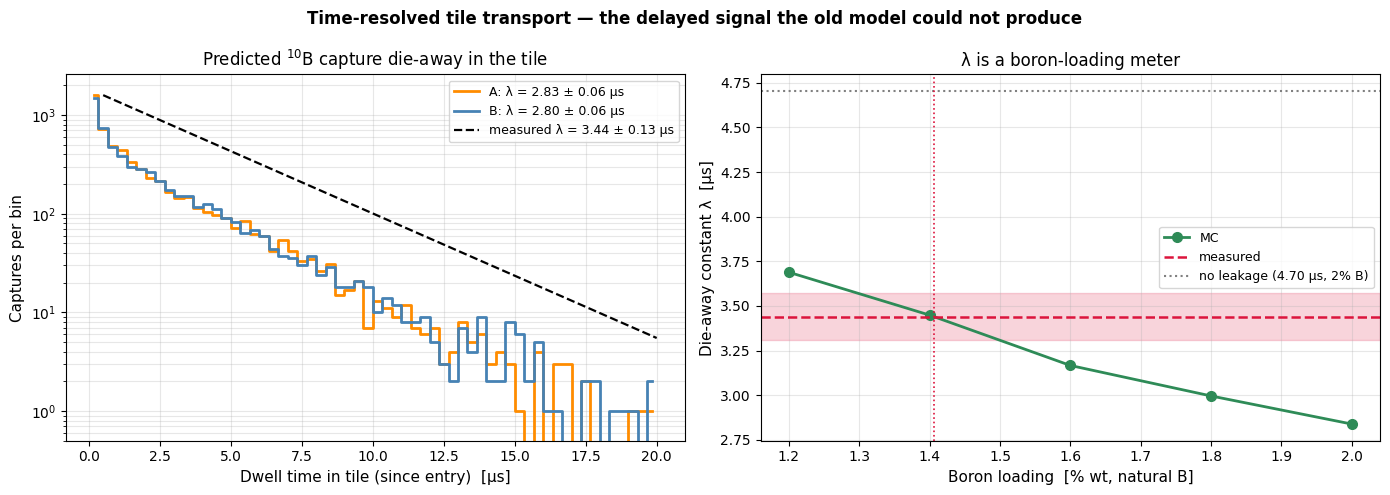

Saved → pns_tile_dieaway.png


In [9]:
# ═══ TIME-RESOLVED TRANSPORT INSIDE THE TILE  →  DIE-AWAY ════════════════════
# The tile is borated PVT: a hydrogenous moderator with the absorber dissolved
# in it.  A neutron arriving epithermal does NOT capture on the way through —
# it scatters, thermalizes locally, random-walks, and then captures on the
# tile's own timescale.  Earlier versions of this notebook modelled the tile as
# a single-pass attenuator, p(E) = 1 − exp(−Σ_B(E)·t) evaluated at the entrance
# energy with zero elapsed time, so a neutron either captured instantly on
# arrival or never.  That model cannot produce a delayed signal at all.
#
# Here each neutron is tracked in the real 3×3×1 cm box with a clock, so every
# capture gets a timestamp and the predicted observable becomes a die-away.

MEAS_LAMBDA_US     = 3.44    # measured die-away, 1 µs gate
MEAS_LAMBDA_ERR_US = 0.13

TILE_X, TILE_Y, TILE_Z = 3.0, 3.0, SCINT_THICKNESS_CM

# ─── Analytic reference scales ───────────────────────────────────────────────
Sigma_a_th_tile = n_B10_scint * SIGMA_B10_THERMAL_BARNS * 1e-24      # [cm⁻¹]
v_th            = neutron_velocity(E_THERMAL_EV)                     # [cm/s]
tau_capture     = 1.0 / (Sigma_a_th_tile * v_th)                     # [s]
mean_chord      = 4 * (TILE_X*TILE_Y*TILE_Z) / (
                  2*(TILE_X*TILE_Y + TILE_Y*TILE_Z + TILE_X*TILE_Z))

print(f"Tile: {TILE_X:g}×{TILE_Y:g}×{TILE_Z:g} cm, {SCINT_BORON_FRAC*100:.1f}% B (natural)")
print(f"  Σ_a(thermal)          : {Sigma_a_th_tile:.4f} cm⁻¹  "
      f"→ capture MFP {1/Sigma_a_th_tile:.3f} cm")
print(f"  pure-capture lifetime : {tau_capture*1e6:.3f} µs   (1/Σ_a v, no leakage)")
print(f"  mean chord 4V/S       : {mean_chord:.3f} cm  → leakage shortens this")

# For a 1/v absorber Σ_a(E)·v(E) = Σ_a(th)·v_th is energy-independent, so the
# capture rate per unit time is the same at every energy.  The die-away
# constant is therefore set by leakage alone and is insensitive to the details
# of the thermal spectrum — including the 25.3 meV energy-floor artifact.

# ─── Cross-section tables for the tile material ──────────────────────────────
_Et      = np.logspace(-3, np.log10(E0_eV*1.5), 3000)
_sHt, _sCt = get_endf_cross_sections(_Et)
_logEt   = np.log(_Et)
_Sst     = (n_H_scint * _sHt + n_C_scint * _sCt) * 1e-24        # Σ_scatter [cm⁻¹]
_fHt     = (n_H_scint * _sHt * 1e-24) / _Sst                    # H fraction


def run_tile_mc(E_in, t_in, N, n_B10=None, tile_z=None, seed=1234):
    """3-D random walk inside the tile with a clock.

    Neutrons enter the front face at normal incidence (the 20° source cone
    makes this a good approximation), carrying their arrival energy and the
    time already elapsed getting there.  Each history ends in a ¹⁰B capture
    (timestamped) or leaks out of the box.

    Returns (capture_times [s], dwell_times [s], n_captured, N), where the
    dwell time is measured from the moment the neutron enters the tile — that
    is the quantity comparable to a measured die-away anchored at gate close,
    while the absolute time also carries the arrival-time spread.
    """
    n_B10   = n_B10_scint if n_B10 is None else n_B10
    tile_z  = TILE_Z     if tile_z is None else tile_z
    rng     = np.random.default_rng(seed)
    E_in    = np.asarray(E_in, float)
    t_in    = np.asarray(t_in, float)
    n_src   = len(E_in)
    t_cap   = []
    t_dwell = []

    for _ in range(N):
        j     = rng.integers(0, n_src)
        E     = float(E_in[j])
        t_ent = float(t_in[j])
        t     = t_ent
        x, y, z = rng.random()*TILE_X, rng.random()*TILE_Y, 0.0
        dx, dy, dz = 0.0, 0.0, 1.0

        while True:
            logE  = np.log(max(E, 1e-3))
            Sig_s = np.interp(logE, _logEt, _Sst)
            Sig_a = n_B10 * SIGMA_B10_THERMAL_BARNS * \
                    np.sqrt(E_THERMAL_EV / max(E, E_THERMAL_EV)) * 1e-24
            Sig_t = Sig_s + Sig_a
            s     = -np.log(rng.random()) / Sig_t

            xn, yn, zn = x + s*dx, y + s*dy, z + s*dz
            if not (0.0 <= xn <= TILE_X and 0.0 <= yn <= TILE_Y
                    and 0.0 <= zn <= tile_z):
                break                                   # leaked out

            t += s / neutron_velocity(max(E, E_THERMAL_EV))
            x, y, z = xn, yn, zn

            if rng.random() * Sig_t < Sig_a:
                t_cap.append(t)                          # ¹⁰B capture
                t_dwell.append(t - t_ent)
                break

            # elastic scatter, exact kinematics
            if rng.random() < np.interp(logE, _logEt, _fHt):
                c = np.sqrt(rng.random())                # H, A = 1
                E = max(E * c * c, E_THERMAL_EV)
            else:
                A  = 12.0                                # C
                cc = 2.0*rng.random() - 1.0
                den = 1.0 + 2.0*A*cc + A*A
                E  = max(E * den / (A + 1.0)**2, E_THERMAL_EV)

            mu  = 2.0*rng.random() - 1.0                 # isotropic re-emission
            ph  = 2.0*np.pi*rng.random()
            st  = np.sqrt(max(1.0 - mu*mu, 0.0))
            dx, dy, dz = st*np.cos(ph), st*np.sin(ph), mu

    return np.array(t_cap), np.array(t_dwell), len(t_cap), N


def fit_dieaway(t_us, t0=2.0):
    """Unbinned MLE decay constant for the exponential tail beyond t0."""
    tail = t_us[t_us > t0]
    if len(tail) < 20:
        return np.nan, np.nan, 0
    lam = float(np.mean(tail - t0))
    return lam, lam/np.sqrt(len(tail)), len(tail)


# ─── Run the tile MC for both samples ────────────────────────────────────────
N_TILE = 300000
print(f"\nTile transport: {N_TILE:,} histories per sample")
_t0 = time_module.time()
for key, s in SAMPLES.items():
    r = RES[key]
    t_cap, t_dw, n_cap, n_tot = run_tile_mc(r['E_surv'], r['t_arrive'], N_TILE,
                                            seed=4242 + ord(key))
    eff        = n_cap / n_tot
    t_cap_us   = t_cap * 1e6
    t_dwell_us = t_dw  * 1e6      # since tile entry — comparable to measurement
    lam, lam_e, n_tail = fit_dieaway(t_dwell_us, t0=2.0)

    r['tile_t_cap_us'] = t_cap_us
    r['tile_t_rel_us'] = t_dwell_us
    r['tile_eff']      = eff
    r['lambda_us']     = lam
    r['lambda_err_us'] = lam_e
    # rate with the *time-resolved* capture efficiency
    r['event_rate_td'] = r['rate_surface'] * eff

    print(f"\n  Sample {key}:")
    print(f"    capture efficiency  : {eff*100:.2f}%   "
          f"(old single-pass ⟨p⟩ = {r['mean_p']*100:.3f}%)")
    print(f"    die-away λ (dwell)  : {lam:.3f} ± {lam_e:.3f} µs   "
          f"(measured {MEAS_LAMBDA_US} ± {MEAS_LAMBDA_ERR_US} µs)")
    print(f"    arrival-time spread : median {np.median(r['t_arrive'])*1e6:.3f} µs, "
          f"mean {np.mean(r['t_arrive'])*1e6:.3f} µs  "
          f"(folds into the absolute-time signal, not into λ)")
    print(f"    B-10 rate (100% duty): {r['event_rate_td']:.1f} Hz   "
          f"(old model: {r['event_rate']:.1f} Hz)")
print(f"\n  ✓ {time_module.time()-_t0:.1f}s")

# ─── Sensitivity of λ to the assumed boron loading ───────────────────────────
print(f"\nDie-away vs boron loading (thermal injection, {TILE_Z:g} cm tile):")
b_scan, lam_scan, eff_scan = [], [], []
for b_frac in [0.012, 0.014, 0.016, 0.018, 0.020]:
    nB = (SCINT_DENSITY * b_frac * SCINT_B10_ENRICHMENT / M_B10_loc) * N_A_loc
    tc, tdw, nc, nt = run_tile_mc(np.array([E_THERMAL_EV]), np.array([0.0]),
                                  40000, n_B10=nB, seed=99)
    lam_b, _, _ = fit_dieaway(tdw*1e6, t0=2.0)
    b_scan.append(b_frac*100); lam_scan.append(lam_b); eff_scan.append(nc/nt)
    print(f"  B = {b_frac*100:.1f}% wt : λ = {lam_b:.2f} µs   ε = {nc/nt*100:.1f}%")

b_best = np.interp(MEAS_LAMBDA_US, lam_scan[::-1], np.array(b_scan)[::-1])
print(f"\n  → measured λ = {MEAS_LAMBDA_US} µs corresponds to "
      f"B ≈ {b_best:.2f}% wt at {TILE_Z:g} cm thickness")

# ─── Plot ────────────────────────────────────────────────────────────────────
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))

tb = np.linspace(0, 20, 61)
for key, s in SAMPLES.items():
    r = RES[key]
    h, _ = np.histogram(r['tile_t_rel_us'], bins=tb)
    axL.step(0.5*(tb[:-1]+tb[1:]), np.maximum(h, 0.1), where='mid',
             color=s['color'], lw=2,
             label=f"{key}: λ = {r['lambda_us']:.2f} ± {r['lambda_err_us']:.2f} µs")
t_ref = np.linspace(0.5, 20, 100)
ref   = np.exp(-(t_ref - 0.5)/MEAS_LAMBDA_US)
axL.plot(t_ref, ref * np.max([np.histogram(RES[k]['tile_t_rel_us'], bins=tb)[0].max()
                              for k in SAMPLES]), 'k--', lw=1.6,
         label=f'measured λ = {MEAS_LAMBDA_US} ± {MEAS_LAMBDA_ERR_US} µs')
axL.set_yscale('log')
axL.set_xlabel('Dwell time in tile (since entry)  [µs]', fontsize=11)
axL.set_ylabel('Captures per bin', fontsize=11)
axL.set_title('Predicted $^{10}$B capture die-away in the tile', fontsize=12)
axL.legend(fontsize=9); axL.grid(True, alpha=0.3, which='both')
axL.set_ylim(bottom=0.5)

axR.plot(b_scan, lam_scan, 'o-', color='seagreen', lw=2, ms=7, label='MC')
axR.axhline(MEAS_LAMBDA_US, color='crimson', ls='--', lw=1.8, label='measured')
axR.axhspan(MEAS_LAMBDA_US - MEAS_LAMBDA_ERR_US,
            MEAS_LAMBDA_US + MEAS_LAMBDA_ERR_US, color='crimson', alpha=0.18)
axR.axhline(tau_capture*1e6, color='gray', ls=':', lw=1.5,
            label=f'no leakage ({tau_capture*1e6:.2f} µs, 2% B)')
axR.axvline(b_best, color='crimson', ls=':', lw=1.2)
axR.set_xlabel('Boron loading  [% wt, natural B]', fontsize=11)
axR.set_ylabel('Die-away constant λ  [µs]', fontsize=11)
axR.set_title('λ is a boron-loading meter', fontsize=12)
axR.legend(fontsize=9); axR.grid(True, alpha=0.3)

fig.suptitle('Time-resolved tile transport — the delayed signal the old model could not produce',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pns_tile_dieaway.png', dpi=130)
plt.show()
print("Saved → pns_tile_dieaway.png")


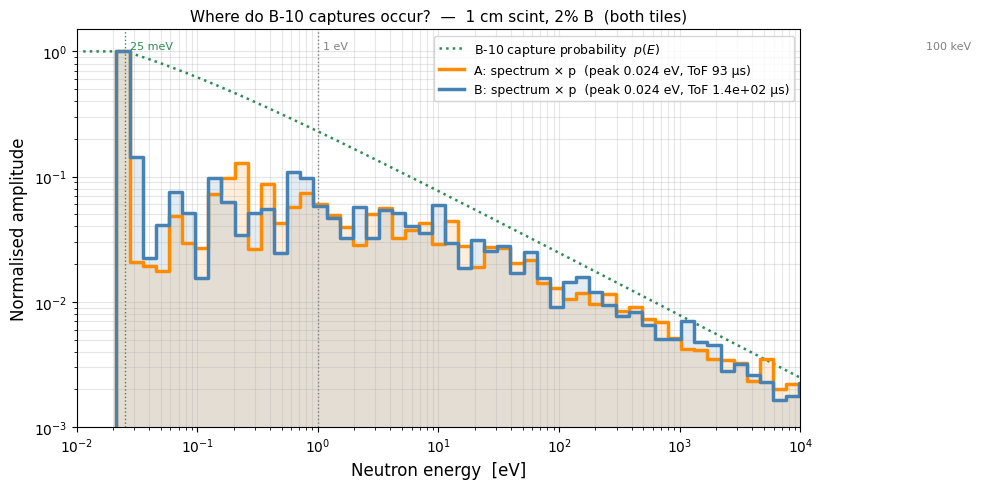

Sample A: peak capture at 0.024 eV  (ToF ≈ 93.2 µs at 20 cm)
Sample B: peak capture at 0.024 eV  (ToF ≈ 140 µs at 30 cm)


In [10]:
# ─── Spectrum × capture probability → where do captures actually happen? ──────
# Same B-10 capture probability curve for both tiles; the weighting spectrum and
# the ToF axis (distance) differ between samples.
bins_cap = np.logspace(np.log10(E_MIN_EV), np.log10(E_MAX_EV), 80)
bc       = np.sqrt(bins_cap[:-1] * bins_cap[1:])

sigma_b10_bc = SIGMA_B10_THERMAL_BARNS * np.sqrt(E_THERMAL_EV / np.maximum(bc, E_THERMAL_EV))
Sigma_b10_bc = n_B10_scint * sigma_b10_bc * 1e-24
p_cap_bc     = 1.0 - np.exp(-Sigma_b10_bc * SCINT_THICKNESS_CM)
pcap_norm    = p_cap_bc / p_cap_bc.max()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(bc, pcap_norm, color='seagreen', lw=1.8, ls=':',
        label='B-10 capture probability  $p(E)$')

for key, s in SAMPLES.items():
    r      = RES[key]
    counts, _ = np.histogram(r['E_surv'], bins=bins_cap)
    capture_rate_density = counts * p_cap_bc
    prod_norm = capture_rate_density / capture_rate_density.max()
    peak_E    = bc[np.argmax(capture_rate_density)]
    peak_tof  = tof_constant_energy(peak_E, r['distance_cm']) * 1e6
    r['peak_E'] = peak_E; r['peak_tof_us'] = peak_tof
    ax.fill_between(bc, prod_norm, alpha=0.15, color=s['color'], step='mid')
    ax.step(bc, prod_norm, where='mid', color=s['color'], lw=2.5,
            label=f'{key}: spectrum × p  (peak {peak_E:.2g} eV, ToF {peak_tof:.2g} µs)')

for E_bound, lb in [(1.0, '1 eV'), (1e5, '100 keV')]:
    ax.axvline(E_bound, color='gray', ls=':', lw=1.0)
    ax.text(E_bound*1.1, 0.97, lb, fontsize=8, va='top', color='gray',
            transform=ax.get_xaxis_transform())
ax.axvline(E_THERMAL_EV, color='seagreen', ls=':', lw=1.0)
ax.text(E_THERMAL_EV*1.1, 0.97, '25 meV', fontsize=8, va='top', color='seagreen',
        transform=ax.get_xaxis_transform())

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Neutron energy  [eV]', fontsize=12)
ax.set_ylabel('Normalised amplitude', fontsize=12)
ax.set_title(f'Where do B-10 captures occur?  —  {SCINT_THICKNESS_CM:.0f} cm scint, '
             f'{SCINT_BORON_FRAC*100:.0f}% B  (both tiles)', fontsize=11)
ax.set_xlim(E_MIN_EV, 1e4); ax.set_ylim(1e-3, 1.5)
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('pns_capture_peak.png', dpi=120)
plt.show()
for key in SAMPLES:
    print(f"Sample {key}: peak capture at {RES[key]['peak_E']:.3g} eV  "
          f"(ToF ≈ {RES[key]['peak_tof_us']:.3g} µs at {RES[key]['distance_cm']:.0f} cm)")


In [11]:
# ─── Bunch structure → time-averaged B-10 capture rate, both samples ─────────
# event_rate (from cell above) assumes EMISSION_RATE = 1e7 n/s at 100% uptime.
# The pulsed machine reduces this by the duty cycle η = τ_on / (τ_on + τ_gap).
SCENARIOS = [
    ('Low duty cycle',   10.0, 200.0),   # τ_on, τ_gap [µs]
    ('High duty cycle',  10.0,  10.0),
    ('100% (reference)',  None, None),
]

def eta_of(t_on, t_gap):
    if t_on is None:
        return 1.0
    return t_on / (t_on + t_gap)

print(f"{'Scenario':<20}{'τ_on':>7}{'τ_gap':>8}{'η':>8}"
      f"{'  R̄_A [Hz]':>12}{'R̄_A /hr':>11}{'  R̄_B [Hz]':>12}{'R̄_B /hr':>11}")
print("-" * 89)
rows = {}
for name, t_on, t_gap in SCENARIOS:
    eta = eta_of(t_on, t_gap)
    rA  = RES['A']['event_rate'] * eta
    rB  = RES['B']['event_rate'] * eta
    rows[name] = (eta, rA, rB)
    ton_s  = '—' if t_on  is None else f'{t_on:.0f}'
    tgap_s = '—' if t_gap is None else f'{t_gap:.0f}'
    print(f"{name:<20}{ton_s:>7}{tgap_s:>8}{eta*100:>7.2f}%"
          f"{rA:>12.3f}{rA*3600:>11.0f}{rB:>12.3f}{rB*3600:>11.0f}")

print()
for _k in SAMPLES:
    print(f"{SAMPLES[_k]['label']}  ({RES[_k]['distance_cm']:.0f} cm from source)")
print(f"\nAt every duty cycle  R̄_B / R̄_A = {RES['B']['event_rate']/RES['A']['event_rate']:.2f} "
      f"(driven by 1/r²  ×  0.5 cm-steel attenuation).")

etaL = rows['Low duty cycle'][0]
print(f"\n╔══════════════════════════════════════════════════════════════════╗")
print(f"║  Time-averaged B-10 capture rate  (low duty cycle, η = {etaL*100:.2f}%)      ║")
print(f"║    Sample A : {rows['Low duty cycle'][1]:.3f} Hz  =  {rows['Low duty cycle'][1]*3600:6.0f} events/hr           ║")
print(f"║    Sample B : {rows['Low duty cycle'][2]:.3f} Hz  =  {rows['Low duty cycle'][2]*3600:6.0f} events/hr           ║")
print(f"╚══════════════════════════════════════════════════════════════════╝")


Scenario               τ_on   τ_gap       η   R̄_A [Hz]   R̄_A /hr   R̄_B [Hz]   R̄_B /hr
-----------------------------------------------------------------------------------------
Low duty cycle           10     200   4.76%       0.603       2171       0.248        894
High duty cycle          10      10  50.00%       6.331      22792       2.608       9387
100% (reference)          —       — 100.00%      12.662      45584       5.215      18775

Sample A — 5 cm air after shield  (20 cm from source)
Sample B — 15 cm from shield, 0.5 cm steel  (30 cm from source)

At every duty cycle  R̄_B / R̄_A = 0.41 (driven by 1/r²  ×  0.5 cm-steel attenuation).

╔══════════════════════════════════════════════════════════════════╗
║  Time-averaged B-10 capture rate  (low duty cycle, η = 4.76%)      ║
║    Sample A : 0.603 Hz  =    2171 events/hr           ║
║    Sample B : 0.248 Hz  =     894 events/hr           ║
╚══════════════════════════════════════════════════════════════════╝


In [12]:
# ─── B-10(n,α) → 478 keV gamma background in the scintillators ────────────────
# Re-run MC tracking depth of each B-10 capture, then transport gammas to tiles
import time as time_module_gamma

print(f"\nGamma background analysis: tracking B-10 capture depth for photon transport")
print(f"Simulating {N_NEUTRONS:,} neutrons with depth-resolved captures...")

boron_cap_z_A = []  # B-HDPE depth [cm] of each B-10 capture in Sample A run
boron_cap_z_B = []  # same for Sample B run
h_cap_z_A = []      # H(n,gamma) capture depths (can be in B-HDPE or wood)
h_cap_z_B = []

n_trans_A = 0; n_trans_B = 0; n_back_A = 0; n_back_B = 0

t0_gamma = time_module_gamma.time()

for sample_key, s in SAMPLES.items():
    layers = build_stack(s['steel_cm'])
    boron_cap_z_list = []
    h_cap_z_list = []
    n_trans = 0; n_back = 0

    Zexit = layers[-1]['z1']
    MU_MIN = np.cos(np.radians(CONE_HALF_ANGLE_DEG))
    EPS = 1e-9
    A_C = 12.0

    for i in range(N_NEUTRONS):
        E = E0_eV; pos = 0.0
        mu = MU_MIN + (1.0 - MU_MIN) * np.random.random()

        while True:
            k = layer_of(pos, layers); lay = layers[k]
            Sigma_scatter = Sigma_scatter_of(E, lay)
            sigma_abs = lay['sigma_abs_th'] * np.sqrt(E_THERMAL_EV / max(E, E_THERMAL_EV))
            Sigma_abs = lay['n_abs'] * sigma_abs * 1e-24
            Sigma_total = Sigma_scatter + Sigma_abs
            step = -np.log(np.random.random()) / Sigma_total

            if mu > 0: dist_face = (lay['z1'] - pos) / mu
            elif mu < 0: dist_face = (pos - lay['z0']) / (-mu)
            else: dist_face = 1e30

            if step >= dist_face:
                pos += dist_face * mu + EPS * np.sign(mu)
                if pos >= Zexit: n_trans += 1; break
                if pos <= 0.0: n_back += 1; break
                continue

            pos += step * mu
            if np.random.random() * Sigma_total < Sigma_abs:
                if lay['abs_is_boron']:
                    boron_cap_z_list.append(pos)  # track depth in B-HDPE only
                break

            if np.random.random() < h_frac(E, lay):
                c = np.sqrt(np.random.random())
                E = max(E * c * c, 0.025); mu = update_mu(mu, c)
                if np.random.random() < ABSORPTION_PROB:
                    h_cap_z_list.append(pos)
                    break
            else:
                cos_CM = 2.0 * np.random.random() - 1.0
                denom = 1.0 + 2.0 * A_C * cos_CM + A_C**2
                E = max(E * denom / (A_C + 1.0)**2, 0.025)
                c = (1.0 + A_C * cos_CM) / np.sqrt(denom)
                mu = update_mu(mu, c)

    if sample_key == 'A':
        boron_cap_z_A = np.array(boron_cap_z_list)
        h_cap_z_A = np.array(h_cap_z_list)
        n_trans_A = n_trans; n_back_A = n_back
    else:
        boron_cap_z_B = np.array(boron_cap_z_list)
        h_cap_z_B = np.array(h_cap_z_list)
        n_trans_B = n_trans; n_back_B = n_back

elapsed_gamma = time_module_gamma.time() - t0_gamma
print(f"  ✓ {elapsed_gamma:.1f}s")
print(f"    A: B10 cap={len(boron_cap_z_A):,}  H cap={len(h_cap_z_A):,}  trans={n_trans_A:,}")
print(f"    B: B10 cap={len(boron_cap_z_B):,}  H cap={len(h_cap_z_B):,}  trans={n_trans_B:,}")

# ─── Photon transport using NIST XCOM polyethylene data ──────────────────────
# Load real XCOM attenuation coefficients
xcom_data = np.loadtxt(os.path.join(os.getcwd(), 'xcom_polyethylene.txt'))
E_xcom_MeV, mu_rho_xcom = xcom_data[:, 0], xcom_data[:, 1]  # cm²/g, total

def mu_rho_PE(E_MeV):
    return np.exp(np.interp(np.log(E_MeV), np.log(E_xcom_MeV), np.log(mu_rho_xcom)))

# Z/A-weighted scaling to other light materials
def ZA_eff(frac_dict):
    ZA = {'H': 1.0/1.008, 'C': 6.0/12.011, 'O': 8.0/16.00, 'B': 5.0/10.81}
    return sum(w * ZA[el] for el, w in frac_dict.items())

ZA_PE = ZA_eff({'H': 0.143, 'C': 0.807})
ZA_BHDPE = ZA_eff({'H': 0.143*0.95, 'C': 0.807*0.95, 'B': 0.05})
ZA_WOOD = ZA_eff({'H': 0.06, 'C': 0.50, 'O': 0.44})
ZA_SCINT = ZA_eff({'H': 0.083*0.98, 'C': 0.897})

def mu_rho_scaled(E_MeV, ZA_target):
    return mu_rho_PE(E_MeV) * (ZA_target / ZA_PE)

# Iron (steel): NIST XCOM reference, log-log interpolated
FE_E_REF = np.array([0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0])
FE_MUR_REF = np.array([0.3717, 0.2749, 0.2177, 0.1660, 0.1394, 0.08414, 0.07223, 0.05876, 0.05995])

def mu_rho_Fe(E_MeV):
    return np.exp(np.interp(np.log(E_MeV), np.log(FE_E_REF), np.log(FE_MUR_REF)))

# Gamma energies and branching ratios
E_GAMMA_B10 = 0.478  # MeV, 7Li* → 7Li deexcitation (dominant line)
BR_B10 = 0.936       # branching ratio to 478 keV state
E_GAMMA_H = 2.223    # MeV, H(n,γ)D line
BR_H = 1.0           # essentially always this line

# Attenuation coefficients at both gamma energies
mu_HDPE_478 = mu_rho_scaled(E_GAMMA_B10, ZA_BHDPE) * BHDPE_DENSITY
mu_WOOD_478 = mu_rho_scaled(E_GAMMA_B10, ZA_WOOD) * WOOD_DENSITY
mu_FE_478 = mu_rho_Fe(E_GAMMA_B10) * STEEL_DENSITY
mu_SCINT_478 = mu_rho_scaled(E_GAMMA_B10, ZA_SCINT) * SCINT_DENSITY

mu_HDPE_2223 = mu_rho_scaled(E_GAMMA_H, ZA_BHDPE) * BHDPE_DENSITY
mu_WOOD_2223 = mu_rho_scaled(E_GAMMA_H, ZA_WOOD) * WOOD_DENSITY
mu_FE_2223 = mu_rho_Fe(E_GAMMA_H) * STEEL_DENSITY
mu_SCINT_2223 = mu_rho_scaled(E_GAMMA_H, ZA_SCINT) * SCINT_DENSITY

p_interact_478 = 1.0 - np.exp(-mu_SCINT_478 * SCINT_THICKNESS_CM)
p_interact_2223 = 1.0 - np.exp(-mu_SCINT_2223 * SCINT_THICKNESS_CM)

print(f"\n478 keV gamma transport parameters:")
print(f"  B-HDPE MFP: {1/mu_HDPE_478:.1f} cm   Wood MFP: {1/mu_WOOD_478:.1f} cm   Steel MFP: {1/mu_FE_478:.1f} cm")
print(f"  Interaction prob in 1 cm scintillator: {p_interact_478*100:.2f}%")
print(f"2.223 MeV gamma transport parameters:")
print(f"  B-HDPE MFP: {1/mu_HDPE_2223:.1f} cm   Wood MFP: {1/mu_WOOD_2223:.1f} cm   Steel MFP: {1/mu_FE_2223:.1f} cm")
print(f"  Interaction prob in 1 cm scintillator: {p_interact_2223*100:.2f}%")



Gamma background analysis: tracking B-10 capture depth for photon transport
Simulating 100,000 neutrons with depth-resolved captures...


  ✓ 10.8s
    A: B10 cap=53,715  H cap=22,939  trans=7,156
    B: B10 cap=53,916  H cap=23,399  trans=6,488

478 keV gamma transport parameters:
  B-HDPE MFP: 9.9 cm   Wood MFP: 16.9 cm   Steel MFP: 1.4 cm
  Interaction prob in 1 cm scintillator: 9.81%
2.223 MeV gamma transport parameters:
  B-HDPE MFP: 21.1 cm   Wood MFP: 35.9 cm   Steel MFP: 2.1 cm
  Interaction prob in 1 cm scintillator: 4.75%


In [13]:
Z1 = PE_THICKNESS_CM
Z2 = PE_THICKNESS_CM + WOOD_THICKNESS_CM
# ─── Compute 478 keV and 2.223 MeV gamma rates at each tile ──────────────────
print(f"\n{'='*75}")
print(f"PHOTON BACKGROUND RATES FROM BORON AND HYDROGEN CAPTURES IN SHIELD")
print(f"{'='*75}")

cone_frac = 0.5 * (1.0 - np.cos(np.radians(CONE_HALF_ANGLE_DEG)))
weight_per_n = EMISSION_RATE * cone_frac / N_NEUTRONS  # [n/s] per simulated neutron

gamma_results = {}

for key in ['A', 'B']:
    r = SAMPLES[key]['distance_cm']
    steel_cm = SAMPLES[key]['steel_cm']
    boron_z = boron_cap_z_A if key == 'A' else boron_cap_z_B
    h_z = h_cap_z_A if key == 'A' else h_cap_z_B

    print(f"\n{'─'*75}")
    print(f"Sample {key} ({r:.0f} cm from source, {steel_cm} cm steel in path)")
    print(f"{'─'*75}")

    # ─── 478 keV gammas from B-10(n,α) ───────────────────────────────────────
    if len(boron_z) > 0:
        d_478 = r - boron_z                           # distance from capture point to tile
        path_hdpe_478 = PE_THICKNESS_CM - boron_z     # remaining B-HDPE after capture
        atten_478 = np.exp(-mu_HDPE_478 * path_hdpe_478
                          - mu_WOOD_478 * WOOD_THICKNESS_CM
                          - mu_FE_478 * steel_cm)
        solid_angle_frac_478 = SURFACE_AREA_CM2 / (4 * np.pi * d_478**2)
        rate_surf_478 = np.sum(weight_per_n * BR_B10 * atten_478 * solid_angle_frac_478)
        rate_interact_478 = rate_surf_478 * p_interact_478

        print(f"\n478 keV gamma (B-10(n,α)⁷Li* → ⁷Li + γ):")
        print(f"  Rate at tile surface  : {rate_surf_478:.2f} /s")
        print(f"  Interaction rate (1cm scint): {rate_interact_478:.2f} /s")
        gamma_results[f'{key}_478'] = (rate_surf_478, rate_interact_478)
    else:
        print(f"\n478 keV gamma: no B-10 captures (unexpected)")
        gamma_results[f'{key}_478'] = (0.0, 0.0)

    # ─── 2.223 MeV gammas from H(n,γ) ────────────────────────────────────────
    if len(h_z) > 0:
        d_2223 = r - h_z
        # H captures can be in B-HDPE (0..14 cm) or wood (14..15 cm)
        in_wood = h_z >= PE_THICKNESS_CM
        path_hdpe_2223 = np.where(in_wood, 0.0, PE_THICKNESS_CM - h_z)
        path_wood_2223 = np.where(in_wood, Z2 - h_z, WOOD_THICKNESS_CM)
        atten_2223 = np.exp(-mu_HDPE_2223 * path_hdpe_2223
                           - mu_WOOD_2223 * path_wood_2223
                           - mu_FE_2223 * steel_cm)
        solid_angle_frac_2223 = SURFACE_AREA_CM2 / (4 * np.pi * d_2223**2)
        rate_surf_2223 = np.sum(weight_per_n * BR_H * atten_2223 * solid_angle_frac_2223)
        rate_interact_2223 = rate_surf_2223 * p_interact_2223

        print(f"\n2.223 MeV gamma (H(n,γ)D):")
        print(f"  Rate at tile surface  : {rate_surf_2223:.2f} /s")
        print(f"  Interaction rate (1cm scint): {rate_interact_2223:.2f} /s")
        gamma_results[f'{key}_2223'] = (rate_surf_2223, rate_interact_2223)
    else:
        print(f"\n2.223 MeV gamma: no H captures (unexpected)")
        gamma_results[f'{key}_2223'] = (0.0, 0.0)

    # ─── Total photon background ──────────────────────────────────────────────
    total_surf = gamma_results[f'{key}_478'][0] + gamma_results[f'{key}_2223'][0]
    total_interact = gamma_results[f'{key}_478'][1] + gamma_results[f'{key}_2223'][1]
    b10_signal = RES[key]['event_rate_td']   # time-resolved tile capture rate

    print(f"\n{'─'*75}")
    print(f"Total photon background (100% duty):")
    print(f"  Rate at surface: {total_surf:.2f} /s")
    print(f"  Interaction rate in tile: {total_interact:.2f} /s")
    print(f"\nComparison to direct B-10(n,α) neutron capture signal (100% duty):")
    print(f"  Neutron signal: {b10_signal:.2f} Hz")
    print(f"  Photon background: {total_interact:.2f} Hz")
    print(f"  Background / Signal ratio: {total_interact/b10_signal:.2f}×")
    print(f"{'─'*75}")

print(f"\n{'='*75}")
print(f"KEY TAKEAWAY")
print(f"{'='*75}")
print(f"\nSample A: Photon background ({gamma_results['A_478'][1]+gamma_results['A_2223'][1]:.1f} Hz)"
      f" ≈ {(gamma_results['A_478'][1]+gamma_results['A_2223'][1])/RES['A']['event_rate_td']:.1f}× "
      f"the neutron signal ({RES['A']['event_rate_td']:.1f} Hz)")
print(f"Sample B: Photon background ({gamma_results['B_478'][1]+gamma_results['B_2223'][1]:.1f} Hz)"
      f" ≈ {(gamma_results['B_478'][1]+gamma_results['B_2223'][1])/RES['B']['event_rate_td']:.2f}× "
      f"the neutron signal ({RES['B']['event_rate_td']:.1f} Hz)")
ratio_A = (gamma_results['A_478'][1]+gamma_results['A_2223'][1])/RES['A']['event_rate_td']
ratio_B = (gamma_results['B_478'][1]+gamma_results['B_2223'][1])/RES['B']['event_rate_td']
T_steel_478  = np.exp(-mu_FE_478  * SAMPLES['B']['steel_cm'])
T_steel_2223 = np.exp(-mu_FE_2223 * SAMPLES['B']['steel_cm'])
print(f"\n0.5 cm steel transmission: {T_steel_478*100:.0f}% at 478 keV, "
      f"{T_steel_2223*100:.0f}% at 2.223 MeV")
print(f"Gamma/signal ratio: {ratio_A:.1f}x (A) -> {ratio_B:.2f}x (B).")
print("Sample B is better on both counts: the steel absorbs part of the gamma flux,")
print("and its capture signal falls more slowly than the gamma flux with distance.")



PHOTON BACKGROUND RATES FROM BORON AND HYDROGEN CAPTURES IN SHIELD

───────────────────────────────────────────────────────────────────────────
Sample A (20 cm from source, 0.0 cm steel in path)
───────────────────────────────────────────────────────────────────────────

478 keV gamma (B-10(n,α)⁷Li* → ⁷Li + γ):
  Rate at tile surface  : 345.30 /s
  Interaction rate (1cm scint): 33.86 /s

2.223 MeV gamma (H(n,γ)D):
  Rate at tile surface  : 208.72 /s
  Interaction rate (1cm scint): 9.91 /s

───────────────────────────────────────────────────────────────────────────
Total photon background (100% duty):
  Rate at surface: 554.03 /s
  Interaction rate in tile: 43.77 /s

Comparison to direct B-10(n,α) neutron capture signal (100% duty):
  Neutron signal: 25.21 Hz
  Photon background: 43.77 Hz
  Background / Signal ratio: 1.74×
───────────────────────────────────────────────────────────────────────────

───────────────────────────────────────────────────────────────────────────
Sample B (30

In [14]:
# ─── Recoil energy from elastic scatters (neutron scattering background) ──────
print(f"\n{'='*75}")
print(f"RECOIL ENERGY SPECTRUM FROM NEUTRON ELASTIC SCATTERS IN SCINTILLATOR")
print(f"{'='*75}")

def E_recoil_max(E_n_eV, A):
    """Maximum recoil energy in lab frame (head-on elastic collision)."""
    return E_n_eV * 4 * A / (A + 1)**2

def mean_E_recoil(E_n_eV, A):
    """Mean recoil energy over all CM angles (isotropic CM scattering)."""
    return E_recoil_max(E_n_eV, A) / 2.0

A_H = 1.0; A_C = 12.0

for key in ['A', 'B']:
    r = RES[key]
    E_surv = r['E_surv']

    # Recoil energies at median transmitted neutron energy (representative)
    E_med = r['fracs']['median_eV']
    E_mean = r['fracs']['mean_eV']

    E_rec_H_med = mean_E_recoil(E_med, A_H)
    E_rec_C_med = mean_E_recoil(E_med, A_C)
    E_rec_H_mean = mean_E_recoil(E_mean, A_H)
    E_rec_C_mean = mean_E_recoil(E_mean, A_C)

    print(f"\nSample {key}:")
    print(f"  Transmitted spectrum: mean E = {E_mean:.2e} eV, median E = {E_med:.2e} eV")
    print(f"  At median energy ({E_med:.2e} eV):")
    print(f"    H(n,p) max recoil: {E_rec_H_med:.0f} eV  (mean over angles: {E_rec_H_med/2:.0f} eV)")
    print(f"    C(n,n') max recoil: {E_rec_C_med:.0f} eV  (mean over angles: {E_rec_C_med/2:.0f} eV)")
    print(f"  At mean energy ({E_mean:.2e} eV):")
    print(f"    H(n,p) mean recoil: {E_rec_H_mean/2:.0f} eV")
    print(f"    C(n,n') mean recoil: {E_rec_C_mean/2:.0f} eV")

print(f"\n{'─'*75}")
print(f"Energy scale for signal identification:")
print(f"  B-10(n,α) Q-value: 1.645 MeV")
print(f"    → dominant 478 keV gamma (not seen in scint directly after escape)")
print(f"    → alpha (E_K ≈ 1.4 MeV in CM) + Li-7 recoil (~100s keV in lab)")
print(f"  Neutron elastic scatters (background):")
print(f"    → H recoil: ~10s–100s keV (depending on incident E)")
print(f"    → C recoil: ~few–10 keV (much lower Z means lower Bethe-Bloch dE/dx)")
print(f"\nConclusion: Pulse-shape discrimination or time-of-flight needed to")
print(f"distinguish high-energy recoils (captures) from neutron scatters.")
print(f"{'='*75}")



RECOIL ENERGY SPECTRUM FROM NEUTRON ELASTIC SCATTERS IN SCINTILLATOR

Sample A:
  Transmitted spectrum: mean E = 1.20e+06 eV, median E = 1.19e+06 eV
  At median energy (1.19e+06 eV):
    H(n,p) max recoil: 595018 eV  (mean over angles: 297509 eV)
    C(n,n') max recoil: 168999 eV  (mean over angles: 84500 eV)
  At mean energy (1.20e+06 eV):
    H(n,p) mean recoil: 300728 eV
    C(n,n') mean recoil: 85414 eV

Sample B:
  Transmitted spectrum: mean E = 1.25e+06 eV, median E = 1.31e+06 eV
  At median energy (1.31e+06 eV):
    H(n,p) max recoil: 654665 eV  (mean over angles: 327332 eV)
    C(n,n') max recoil: 185940 eV  (mean over angles: 92970 eV)
  At mean energy (1.25e+06 eV):
    H(n,p) mean recoil: 313531 eV
    C(n,n') mean recoil: 89050 eV

───────────────────────────────────────────────────────────────────────────
Energy scale for signal identification:
  B-10(n,α) Q-value: 1.645 MeV
    → dominant 478 keV gamma (not seen in scint directly after escape)
    → alpha (E_K ≈ 1.4 MeV 

In [15]:
# ─── Recoil energy comparison: Boron scintillator vs NaI crystal ───────────
print(f"\n{'='*80}")
print(f"RECOIL ENERGY COMPARISON: BORON SCINTILLATOR vs NaI CRYSTAL")
print(f"{'='*80}")

A_Na = 23.0
A_I = 127.0

# For NaI: assume equal atom fractions (idealized, real NaI = Na + I by stoichiometry)
# Density: 3.67 g/cm³, composition: Na ~15.3% by mass, I ~84.7% by mass

for key in ['A', 'B']:
    r = RES[key]
    E_surv = r['E_surv']
    E_med = r['fracs']['median_eV']
    E_mean = r['fracs']['mean_eV']

    print(f"\n{'─'*80}")
    print(f"Sample {key}: Transmitted neutron spectrum (mean {E_mean:.2e} eV, median {E_med:.2e} eV)")
    print(f"{'─'*80}")

    # Boron scintillator (PVT, ~C₉H₁₀ with 2% B)
    print(f"\nBoron Scintillator (PVT-based, ~C₉H₁₀ + 2% B):")
    print(f"  H(n,p):   max recoil = {mean_E_recoil(E_med, 1.0)*2:.0f} eV  "
          f"(mean = {mean_E_recoil(E_med, 1.0):.0f} eV)")
    print(f"  C(n,n'):  max recoil = {mean_E_recoil(E_med, 12.0)*2:.0f} eV  "
          f"(mean = {mean_E_recoil(E_med, 12.0):.0f} eV)")
    print(f"  → Dominant scatters from light nuclei (H, C)")
    print(f"  → High recoil energy and strong ionization signal")

    # NaI crystal
    print(f"\nNaI Crystal (Na-I compound, ρ ≈ 3.67 g/cm³):")
    E_rec_Na_max = mean_E_recoil(E_med, A_Na) * 2
    E_rec_Na_mean = mean_E_recoil(E_med, A_Na)
    E_rec_I_max = mean_E_recoil(E_med, A_I) * 2
    E_rec_I_mean = mean_E_recoil(E_med, A_I)

    print(f"  Na(n,n'): max recoil = {E_rec_Na_max:.0f} eV  "
          f"(mean = {E_rec_Na_mean:.0f} eV)")
    print(f"  I(n,n'):  max recoil = {E_rec_I_max:.0f} eV  "
          f"(mean = {E_rec_I_mean:.0f} eV)")
    print(f"  → Scatters primarily off much heavier nuclei")
    print(f"  → MUCH lower recoil energy")
    print(f"  → Severely reduced ionization signal")

    # Quantitative comparison
    ratio_na = E_rec_Na_mean / mean_E_recoil(E_med, 1.0)
    ratio_i = E_rec_I_mean / mean_E_recoil(E_med, 1.0)

    print(f"\nEnergy ratio (NaI / Boron scint):")
    print(f"  Na recoil / H recoil:  {ratio_na:.3f}  (factor of {1/ratio_na:.0f}× lower)")
    print(f"  I recoil / H recoil:   {ratio_i:.3f}  (factor of {1/ratio_i:.0f}× lower)")

print(f"\n{'='*80}")
print(f"CONCLUSION FOR NEUTRON DETECTION:")
print(f"{'='*80}")
print(f"""
NaI crystals are POOR for neutron detection because:
  1. Nuclei are very heavy (Na mass 23, I mass 127)
     → Recoil energy ∝ 4A/(A+1)² drops as 1/A for large A
     → NaI recoils are ~50-100× weaker than boron scintillator

  2. Lower recoil energy → Lower ionization (∝ E^0.8 for light nuclei)
     → Signal-to-noise ratio is terrible for fast neutrons

  3. NaI works well for gamma rays (high-Z for photoelectric absorption)
     but is nearly transparent to fast neutrons with minimal ionization

Boron-doped scintillators are DESIGNED for neutron detection:
  ✓ Light nuclei (H, C) give high recoil energies
  ✓ B-10 gives BOTH elastic scatters AND thermal capture (1645 keV signal)
  ✓ Natural discrimination via pulse-shape or ToF
  ✓ Orders of magnitude better than heavy-nucleus detectors
""")
print(f"{'='*80}")



RECOIL ENERGY COMPARISON: BORON SCINTILLATOR vs NaI CRYSTAL

────────────────────────────────────────────────────────────────────────────────
Sample A: Transmitted neutron spectrum (mean 1.20e+06 eV, median 1.19e+06 eV)
────────────────────────────────────────────────────────────────────────────────

Boron Scintillator (PVT-based, ~C₉H₁₀ + 2% B):
  H(n,p):   max recoil = 1190036 eV  (mean = 595018 eV)
  C(n,n'):  max recoil = 337998 eV  (mean = 168999 eV)
  → Dominant scatters from light nuclei (H, C)
  → High recoil energy and strong ionization signal

NaI Crystal (Na-I compound, ρ ≈ 3.67 g/cm³):
  Na(n,n'): max recoil = 190075 eV  (mean = 95038 eV)
  I(n,n'):  max recoil = 36898 eV  (mean = 18449 eV)
  → Scatters primarily off much heavier nuclei
  → MUCH lower recoil energy
  → Severely reduced ionization signal

Energy ratio (NaI / Boron scint):
  Na recoil / H recoil:  0.160  (factor of 6× lower)
  I recoil / H recoil:   0.031  (factor of 32× lower)

─────────────────────────────

ELASTIC-SCATTER BACKGROUND vs ¹⁰B CAPTURE SIGNAL

Sample A:
  H recoils      :    246.3 Hz
  C recoils      :    114.0 Hz
  total scatter  :    360.3 Hz
  ¹⁰B capture    :     25.2 Hz
  scatter/capture:       14×

Sample B:
  H recoils      :     96.4 Hz
  C recoils      :     46.4 Hz
  total scatter  :    142.8 Hz
  ¹⁰B capture    :     10.1 Hz
  scatter/capture:       14×


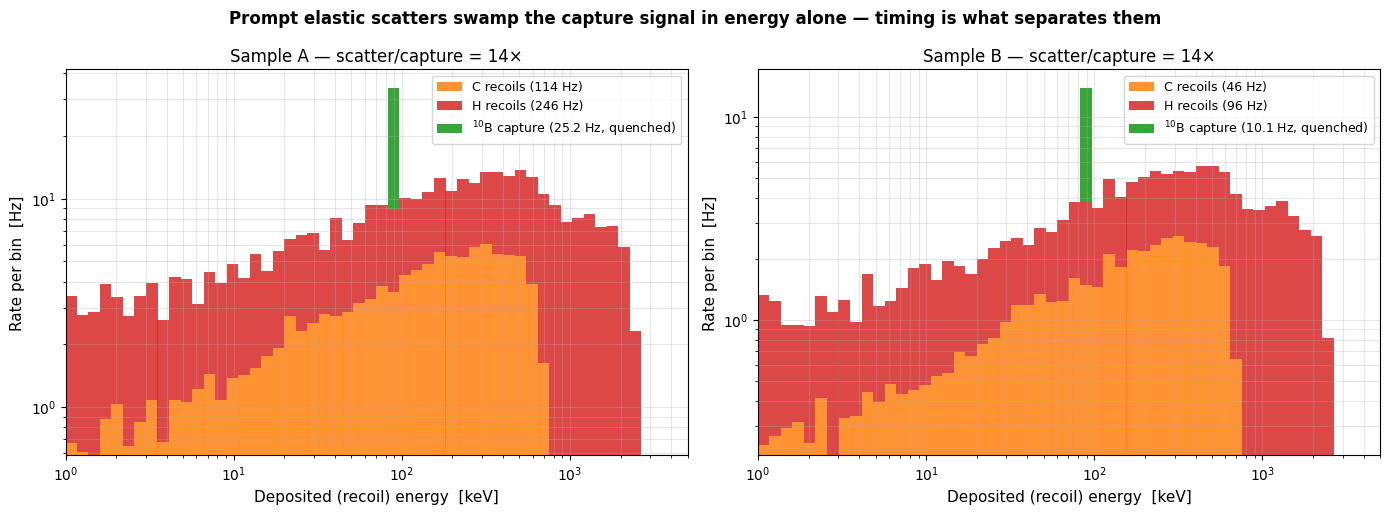


──────────────────────────────────────────────────────────────────────────────
The scatters are prompt (they arrive with the fast flux, within ~100 ns of
the pulse) while the captures follow the ~3 µs die-away.  Energy alone
does not separate them; the time structure does.
──────────────────────────────────────────────────────────────────────────────


In [16]:
# ═══ ELASTIC-SCATTER BACKGROUND vs ¹⁰B CAPTURE, BY DEPOSITED ENERGY ══════════
# NOTE: an earlier version of this cell normalised the two histograms to
# hard-coded fractions of the capture rate (0.5 and 0.05), so it reported a
# scatter/capture ratio of 0.55× *by construction* — identical for both
# samples, and in direct contradiction with the ~40× from the rate cell above.
# The rates below are taken from the MC (r['total_scatter_rate'] and
# r['total_capture_rate']); nothing here is normalised by hand.

print(f"{'='*78}")
print("ELASTIC-SCATTER BACKGROUND vs ¹⁰B CAPTURE SIGNAL")
print(f"{'='*78}")


def E_recoil_max(E_n_eV, A):
    """Maximum lab-frame recoil energy (head-on elastic collision)."""
    return E_n_eV * 4.0 * A / (A + 1.0)**2


E_dep_bins = np.logspace(0, 3.7, 55)          # 1 keV … 5 MeV
E_dep_ctr  = np.sqrt(E_dep_bins[:-1] * E_dep_bins[1:])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

for ax, (key, s) in zip(axes, SAMPLES.items()):
    r      = RES[key]
    E_surv = r['E_surv']

    sigma_H_mc, sigma_C_mc = get_endf_cross_sections(E_surv)
    Sig_H = n_H_scint * sigma_H_mc * 1e-24
    Sig_C = n_C_scint * sigma_C_mc * 1e-24

    # per-neutron probability of at least one elastic scatter in the tile,
    # split between H and C by their share of Σ_scatter
    p_scat = 1.0 - np.exp(-(Sig_H + Sig_C) * SCINT_THICKNESS_CM)
    f_H    = Sig_H / (Sig_H + Sig_C)
    w_n    = r['rate_surface'] / len(E_surv)          # [Hz] per simulated neutron

    # recoil energy: sample cosθ_CM so the deposited spectrum is the real
    # flat-in-recoil distribution, not just the endpoint
    u_H = np.random.random(len(E_surv))
    u_C = np.random.random(len(E_surv))
    E_rec_H = E_recoil_max(E_surv, 1.0)  * u_H / 1e3      # → keV
    E_rec_C = E_recoil_max(E_surv, 12.0) * u_C / 1e3

    h_H, _ = np.histogram(E_rec_H, bins=E_dep_bins, weights=w_n * p_scat * f_H)
    h_C, _ = np.histogram(E_rec_C, bins=E_dep_bins, weights=w_n * p_scat * (1 - f_H))

    # capture signal: the α + ⁷Li pair deposits the full 2.31 MeV Q-value
    # locally, but quenching in plastic puts the visible light near ~90 keVee.
    cap_rate  = r['rate_surface'] * r['tile_eff']
    E_cap_kev = 93.0
    h_cap = np.zeros_like(h_H)
    h_cap[np.argmin(np.abs(E_dep_ctr - E_cap_kev))] = cap_rate

    ax.bar(E_dep_ctr, h_C, width=np.diff(E_dep_bins), color='tab:orange',
           alpha=0.85, label=f'C recoils ({h_C.sum():.0f} Hz)')
    ax.bar(E_dep_ctr, h_H, width=np.diff(E_dep_bins), bottom=h_C,
           color='tab:red', alpha=0.85, label=f'H recoils ({h_H.sum():.0f} Hz)')
    ax.bar(E_dep_ctr, h_cap, width=np.diff(E_dep_bins), bottom=h_C + h_H,
           color='tab:green', alpha=0.95,
           label=f'$^{{10}}$B capture ({cap_rate:.1f} Hz, quenched)')

    ratio = (h_H.sum() + h_C.sum()) / cap_rate
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Deposited (recoil) energy  [keV]', fontsize=11)
    ax.set_ylabel('Rate per bin  [Hz]', fontsize=11)
    ax.set_title(f'Sample {key} — scatter/capture = {ratio:.0f}×', fontsize=12)
    ax.legend(fontsize=9, loc='upper right'); ax.grid(True, alpha=0.3, which='both')
    ax.set_xlim(1, 5e3)

    r['scatter_over_capture'] = ratio
    print(f"\nSample {key}:")
    print(f"  H recoils      : {h_H.sum():8.1f} Hz")
    print(f"  C recoils      : {h_C.sum():8.1f} Hz")
    print(f"  total scatter  : {h_H.sum()+h_C.sum():8.1f} Hz")
    print(f"  ¹⁰B capture    : {cap_rate:8.1f} Hz")
    print(f"  scatter/capture: {ratio:8.0f}×")

fig.suptitle('Prompt elastic scatters swamp the capture signal in energy alone — '
             'timing is what separates them', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pns_scatter_vs_capture_spectrum.png', dpi=130)
plt.show()

print(f"\n{'─'*78}")
print("The scatters are prompt (they arrive with the fast flux, within ~100 ns of")
print("the pulse) while the captures follow the ~3 µs die-away.  Energy alone")
print("does not separate them; the time structure does.")
print(f"{'─'*78}")
